# Enhancing Time-Series Forecasting with Machine Learning through Structural-Break Identification — a GRU study

**Research project · Data Science and Business Analytics, HSE University**

This notebook is the experimental engine for the GRU version of the project. It reproduces, **for the Gated Recurrent Unit (GRU)**, the full pipeline used in the LSTM coursework (Burlakov) and draws its experimental constants (noise types, amplitudes, horizons, epochs) from the group journal plan (*TimeSeries 2026, Journal of Forecasting*).

## What this notebook delivers (maps 1-to-1 onto the report sections)

| Notebook part | Report section to write | Output you harvest |
|---|---|---|
| **1. Setup** | Implementation details / reproducibility | config table |
| **2. Synthetic data generation** | *Methodology · Synthetic Data Generation* | Figs: switching+relaxation, $\Delta t$ effect, noise gallery, example series |
| **3. Observed breaks & interval analysis** | *Observed Break Labels and Interval Analysis* | inter-break interval histograms |
| **4. Structural-break detection** | *Structural Break Analysis · PELT / Chow* | detection table (PELT vs Chow), penalty sensitivity, overlay fig |
| **5. Forecasting models (plain & hybrid GRU)** | *Feature Engineering · GRU Forecasting · Why PELT in the hybrid* | model definitions, single-series demo |
| **6. Experiments** | *Experimental Results* | per-noise table, horizon sweep, $\alpha$ sensitivity, global comparison |
| **7. Signed 3-class + factorial design** | *Simulation design · classification* | 6×3×2×10 factorial table, binary-vs-signed, confusion matrix |
| **8. Discussion / limitations / future work** | *Discussion · Limitations · Conclusion* | offline-vs-causal hybrid, bullet points |

## The central narrative (your hint, implemented)
1. **A plain GRU** forecasts the noisy non-stationary series. It is fair but *imperfect*, especially on coloured noise.
2. **PELT** (and Chow as a classical comparison) identifies the structural breaks.
3. **A hybrid GRU** receives PELT segment statistics as extra features. It is consistently more accurate — most of all for **autocorrelated / structured** noise (red, pink, El&nbsp;Niño).
4. We separate the **offline** hybrid (value of *accurate* break knowledge — an informative upper bound) from a **causal/online** variant, and use the gap to motivate dynamic model adaptation.

> **Honesty note baked into the design.** The headline hybrid uses PELT applied to the *whole* observed series (offline change-point analysis). This measures *the value of explicit break identification* — exactly the project goal — and is an upper bound for streaming use. Part&nbsp;7 quantifies the online-realizable (causal) version.

## 1 · Setup and reproducibility

All randomness is seeded (NumPy + PyTorch). Heavy cells respect the `QUICK` switch so you can iterate fast and then do one full run to harvest the figures/tables. Outputs are written to `figures/` and `results/`.

In [1]:
import os, time, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from scipy.signal import find_peaks
from scipy import stats
from sklearn.metrics import average_precision_score, roc_auc_score, balanced_accuracy_score, f1_score, precision_score, recall_score
from sklearn.ensemble import GradientBoostingRegressor
warnings.filterwarnings("ignore")
%matplotlib inline

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "font.size": 10, "figure.autolayout": True})

# ----- global experiment configuration -----------------------------------
QUICK = False   # True -> 1 seed, fewer epochs (fast smoke run); False -> full run (~10-15 min)

CFG = dict(
    n          = 10000,                 # series length
    dt         = 1.0,                  # integration step (Delta t)
    T          = 25.0,                 # characteristic residence time -> mean segment length
    level_sigma= 1.5,                  # std of the random piecewise-constant regime levels
    L          = 12,                   # GRU input window length
    hidden     = 64,                   # GRU hidden size  (from the LSTM coursework)
    lr         = 1e-3,                 # Adam learning rate
    batch      = 128,                  # mini-batch size  (from the LSTM coursework)
    epochs     = 12,                   # training epochs   (journal plan uses ~8; we use 12)
    seeds      = [0, 1, 2],            # repetitions for the sweeps (stable averages)
    n_seeds_sig= 10,                   # repetitions for the headline table (error bars + significance)
    beta       = 2.0,                  # PELT penalty multiplier
    tol        = 3,                    # tolerance (steps) for break-aware residual labels
    det_tol    = 5,                    # tolerance (steps) for detection localisation
    noises     = ["white", "pink", "red", "blue", "violet", "el_nino"],
    alphas     = [1.0, 2.0, np.pi],    # noise amplitudes  (journal plan: {1, 2, pi})
    horizons   = [2, 5, 10, 25],       # forecast horizons (journal plan: {1,2,5,10,25})
    main_alpha = 1.0,
    main_h     = 10,
    fact_seeds = list(range(10)),      # 10 repetitions for the 6x3x2x10 factorial design
    fact_epochs= 25,                   # epochs for the classification factorial
)
if QUICK:
    CFG.update(seeds=[0], epochs=6, n_seeds_sig=3, fact_seeds=list(range(2)), fact_epochs=10)

def set_seed(s):
    np.random.seed(s); torch.manual_seed(s)

set_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE, "| torch", torch.__version__, "| QUICK =", QUICK)
pd.DataFrame([CFG]).T.rename(columns={0: "value"})

device: cpu | torch 2.12.0+cpu | QUICK = False


,value
n,10000
dt,1.0
T,25.0
level_sigma,1.5
L,12
hidden,64
lr,0.001
batch,128
epochs,12
seeds,"[0, 1, 2]"


## 2 · Synthetic data generation

We study structural breaks under **fully controlled** conditions, so the ground truth is known. The data-generating process is

$$x(t) \;=\; L(t) \;+\; \alpha\, N_\beta(t),$$

where:

* **$L(t)$** is a **piecewise-constant regime signal** (a generalised telegraph process). Inter-switch intervals follow a geometric law with per-step probability $p=\Delta t/T$, so the mean segment length is $T/\Delta t$. After every switch the *observed* level relaxes exponentially toward the new regime with timescale $\tau=\max(4\Delta t,\,0.2T)$, so breaks are visible but not instantaneous.
* **$N_\beta(t)$** is unit-variance **coloured noise** with power spectral density $S(f)\propto 1/f^{\beta}$ — white ($\beta{=}0$), pink ($1$), red/brown ($2$), blue ($-1$), violet ($-2$) — plus a structured **El&nbsp;Niño** process (two random sinusoids + an AR(1) term).
* **$\alpha\in\{1,2,\pi\}$** scales the noise.

> The canonical references use a **binary** $\pm1$ telegraph (shown in Fig.&nbsp;1 below). For the forecasting study we use **random continuous segment levels** so that each new regime is genuinely unpredictable from the past — this turns regime-tracking into a non-trivial learning problem instead of a sign-reading task.

### 2.1 Coloured noise

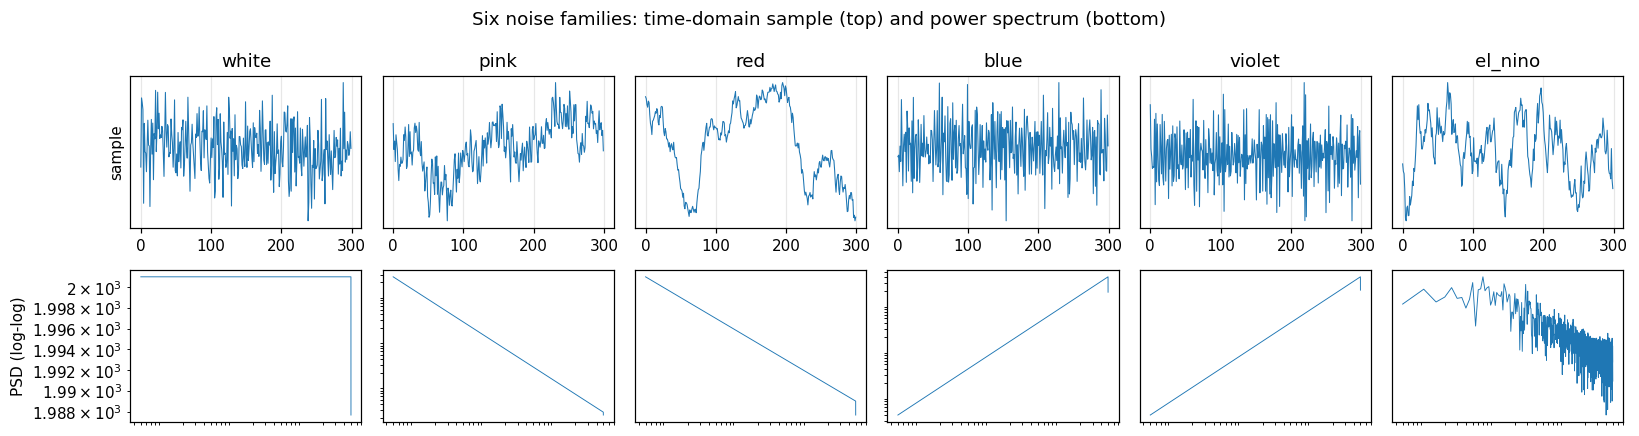

In [2]:
def colored_noise(n, beta, rng):
    """Power-law noise, PSD ~ 1/f^beta  (Timmer & Koenig, 1995)."""
    f = np.fft.rfftfreq(n)
    f[0] = f[1] if len(f) > 1 else 1.0
    amp = f ** (-beta / 2.0)
    phases = rng.uniform(0, 2 * np.pi, len(f))
    spec = amp * (np.cos(phases) + 1j * np.sin(phases))
    spec[0] = 0.0
    x = np.fft.irfft(spec, n=n)
    return (x - x.mean()) / (x.std() + 1e-12)

def el_nino_noise(n, rng):
    """Two random sinusoids + a strongly autocorrelated AR(1) component."""
    t = np.arange(n)
    p1, p2 = rng.uniform(30, 70), rng.uniform(80, 140)
    s = (np.sin(2*np.pi*t/p1 + rng.uniform(0, 2*np.pi))
         + 0.5*np.sin(2*np.pi*t/p2 + rng.uniform(0, 2*np.pi)))
    ar = np.zeros(n); phi = 0.92; e = rng.normal(size=n)
    for i in range(1, n):
        ar[i] = phi*ar[i-1] + e[i]
    x = s + ar
    return (x - x.mean()) / (x.std() + 1e-12)

NOISE_BETA = {"white": 0.0, "pink": 1.0, "red": 2.0, "blue": -1.0, "violet": -2.0}

def make_noise(noise, n, rng):
    return el_nino_noise(n, rng) if noise == "el_nino" else colored_noise(n, NOISE_BETA[noise], rng)

# Gallery: a sample + its periodogram for each noise type
fig, axes = plt.subplots(2, 6, figsize=(15, 4))
rng = np.random.default_rng(0)
for j, noise in enumerate(CFG["noises"]):
    z = make_noise(noise, 2000, rng)
    axes[0, j].plot(z[:300], lw=0.7); axes[0, j].set_title(noise); axes[0, j].set_yticks([])
    f = np.fft.rfftfreq(len(z)); P = np.abs(np.fft.rfft(z))**2
    axes[1, j].loglog(f[1:], P[1:], lw=0.6)
    axes[1, j].set_xticks([]); axes[1, j].set_yticks([])
axes[0, 0].set_ylabel("sample"); axes[1, 0].set_ylabel("PSD (log-log)")
fig.suptitle("Six noise families: time-domain sample (top) and power spectrum (bottom)")
plt.savefig("figures/noise_gallery.png", bbox_inches="tight"); plt.show()

### 2.2 The regime signal: switching + relaxation

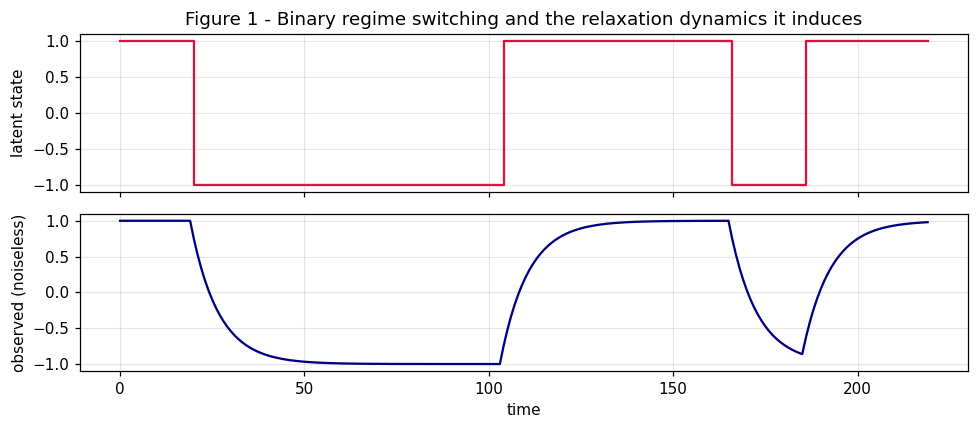

In [3]:
def generate_series(noise="white", alpha=1.0, n=3000, dt=1.0, T=25.0,
                    level=1.0, level_mode="random", level_sigma=1.5, seed=0):
    """Returns (observed series, latent piecewise-constant level, true break indices)."""
    rng = np.random.default_rng(seed)
    p = dt / T                                    # per-step switch probability
    latent = np.empty(n)
    if level_mode == "binary":                    # canonical +-1 telegraph (illustrative)
        s = rng.choice([-1.0, 1.0])
        for i in range(n):
            if rng.random() < p: s = -s
            latent[i] = s
        latent *= level
    else:                                         # random continuous segment levels (study DGP)
        cur = rng.normal(0, level_sigma)
        for i in range(n):
            if rng.random() < p: cur = rng.normal(0, level_sigma)
            latent[i] = cur
    tau = max(4*dt, 0.2*T); a = dt/tau             # exponential relaxation toward new level
    obs = np.empty(n); x = latent[0]
    for i in range(n):
        x += a*(latent[i]-x); obs[i] = x
    x_obs = obs + alpha*make_noise(noise, n, rng)
    true_breaks = np.where(np.diff(latent) != 0)[0] + 1
    return x_obs, latent, true_breaks

# Figure 1 : binary switching mechanism + the relaxation it induces (no noise)
_, latent_b, _ = generate_series("white", 0.0, n=220, T=40, level_mode="binary", seed=3)
rng = np.random.default_rng(3); p = 1/40; s = 1.0; lat = []
for i in range(220):
    if rng.random() < p: s = -s
    lat.append(s)
lat = np.array(lat); tau = max(4*1, 0.2*40); a = 1/tau
obs = np.empty(220); x = lat[0]
for i in range(220): x += a*(lat[i]-x); obs[i] = x
fig, ax = plt.subplots(2, 1, figsize=(9, 4), sharex=True)
ax[0].step(range(220), lat, where="post", color="crimson"); ax[0].set_ylabel("latent state")
ax[0].set_title("Figure 1 - Binary regime switching and the relaxation dynamics it induces")
ax[1].plot(obs, color="navy"); ax[1].set_ylabel("observed (noiseless)"); ax[1].set_xlabel("time")
plt.savefig("figures/fig1_switching_relaxation.png", bbox_inches="tight"); plt.show()

### 2.3 Effect of the integration step $\Delta t$, and a gallery of the study series

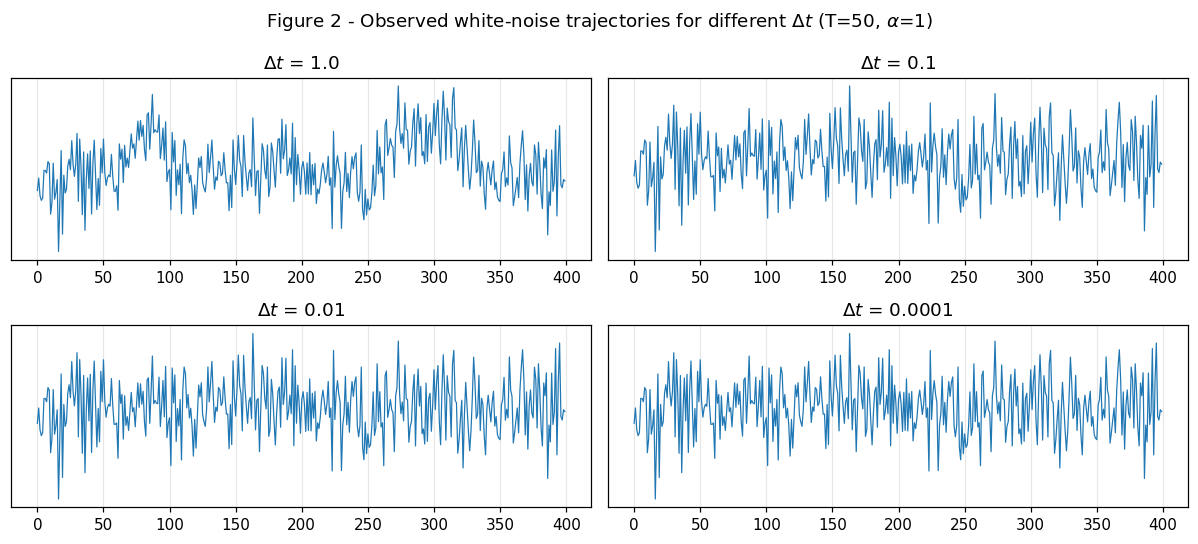

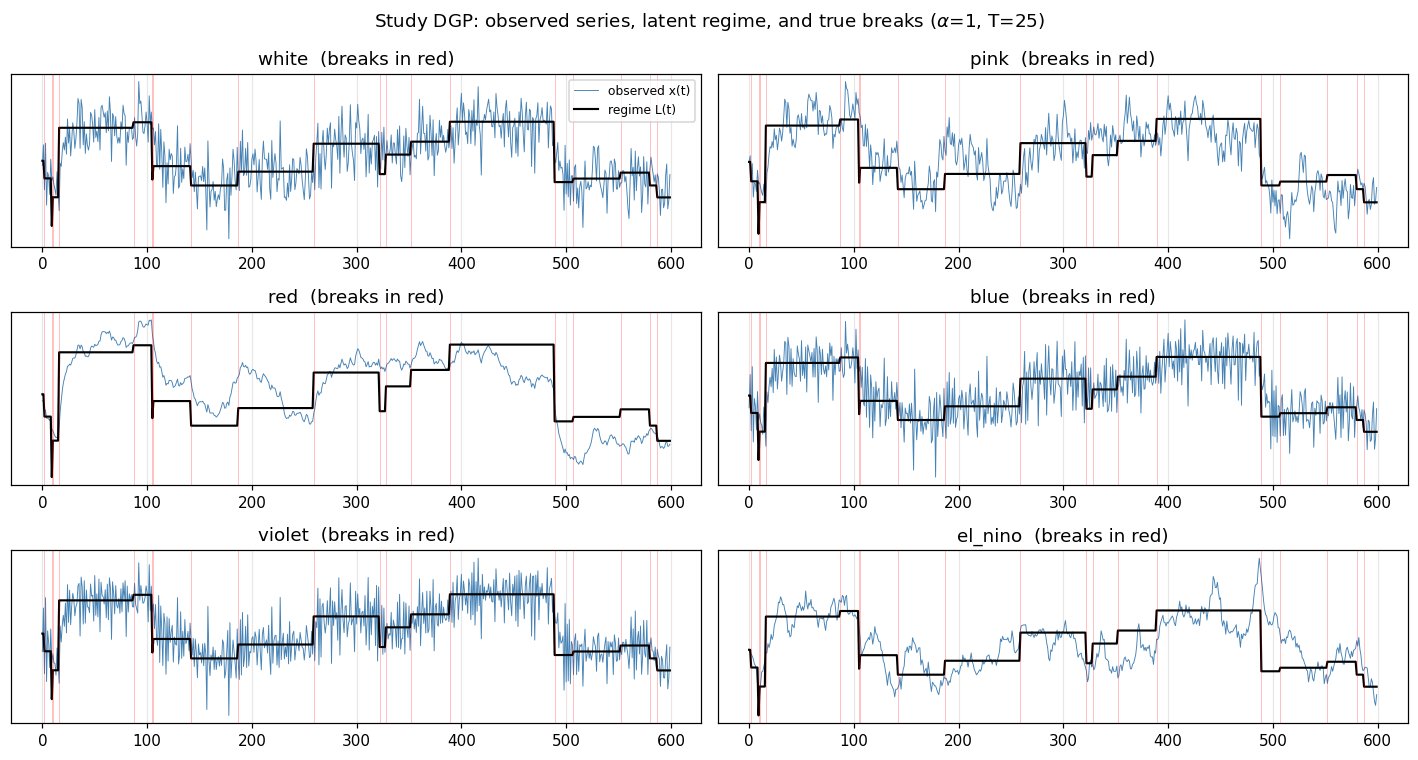

In [4]:
# Figure 2 : same switching ODE, different Delta t  (faithful to the LSTM coursework Fig. 2)
fig, axes = plt.subplots(2, 2, figsize=(11, 5))
for ax, dt in zip(axes.ravel(), [1.0, 0.1, 0.01, 0.0001]):
    x, _, _ = generate_series("white", 1.0, n=400, dt=dt, T=50, level_mode="binary", seed=1)
    ax.plot(x, lw=0.8); ax.set_title(f"$\\Delta t$ = {dt}"); ax.set_yticks([])
fig.suptitle("Figure 2 - Observed white-noise trajectories for different $\\Delta t$ (T=50, $\\alpha$=1)")
plt.savefig("figures/fig2_delta_t.png", bbox_inches="tight"); plt.show()

# Gallery of the actual STUDY series (random levels) with ground-truth breaks marked
fig, axes = plt.subplots(3, 2, figsize=(13, 7))
for ax, noise in zip(axes.ravel(), CFG["noises"]):
    x, lat, tb = generate_series(noise, CFG["main_alpha"], n=600, dt=CFG["dt"],
                                 T=CFG["T"], level_sigma=CFG["level_sigma"], seed=0)
    ax.plot(x, lw=0.6, color="steelblue", label="observed x(t)")
    ax.plot(lat, lw=1.4, color="black", label="regime L(t)")
    for b in tb[tb < 600]:
        ax.axvline(b, color="red", lw=0.4, alpha=0.4)
    ax.set_title(f"{noise}  (breaks in red)"); ax.set_yticks([])
axes[0, 0].legend(fontsize=8, loc="upper right")
fig.suptitle("Study DGP: observed series, latent regime, and true breaks ($\\alpha$=1, T=25)")
plt.savefig("figures/series_gallery.png", bbox_inches="tight"); plt.show()

## 3 · Observed break labels and inter-break interval analysis

Before any model is trained we characterise the **generator itself**. Following the coursework, candidate breaks are read off the absolute first difference $d_t=|x_t-x_{t-1}|$ by peak-picking with a height threshold $c\cdot\mathrm{std}(d)$ and a minimum separation $\max(4\Delta t,0.2T)$. The resulting **inter-break interval** distribution is a fingerprint of each noise regime — high-frequency noises (blue/violet) fragment the difference signal, autocorrelated noises (red/El&nbsp;Niño) produce longer, smoother intervals.

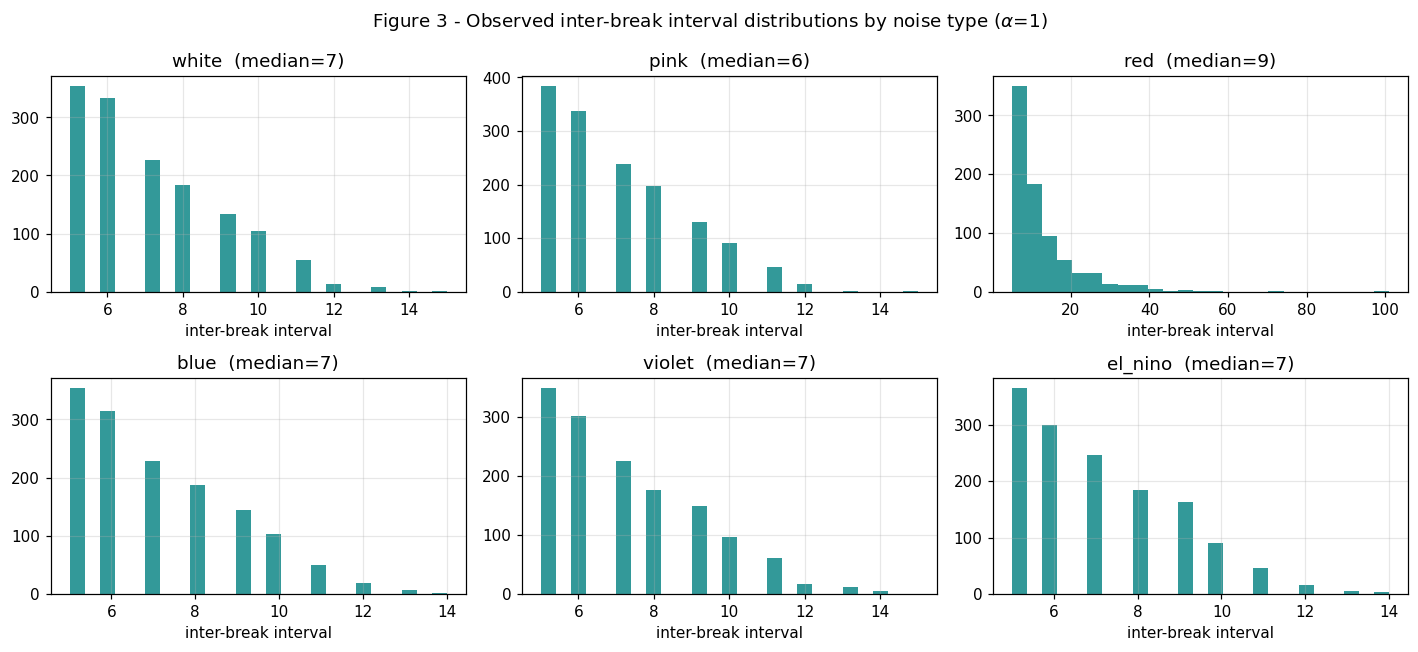

In [5]:
def observed_breaks(x, dt=1.0, T=25.0, c=0.5):
    d = np.abs(np.diff(x))
    dist = max(1, int(round(max(4*dt, 0.2*T))))
    peaks, _ = find_peaks(d, height=c*d.std(), distance=dist)
    return peaks + 1

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, noise in zip(axes.ravel(), CFG["noises"]):
    x, _, _ = generate_series(noise, CFG["main_alpha"], n=CFG["n"], dt=CFG["dt"],
                              T=CFG["T"], level_sigma=CFG["level_sigma"], seed=0)
    ob = observed_breaks(x, CFG["dt"], CFG["T"])
    iv = np.diff(ob)
    ax.hist(iv, bins=25, color="teal", alpha=0.8)
    ax.set_title(f"{noise}  (median={np.median(iv):.0f})")
    ax.set_xlabel("inter-break interval")
fig.suptitle("Figure 3 - Observed inter-break interval distributions by noise type ($\\alpha$=1)")
plt.savefig("figures/fig3_interval_hist.png", bbox_inches="tight"); plt.show()

## 4 · Structural-break detection

We implement two classical detectors and use a third, neural one later:

* **PELT** (Pruned Exact Linear Time; Killick et al. 2012) — exact optimal segmentation under an $\ell_2$ (change-in-mean) cost with a linear penalty, $\mathcal{O}(n)$ expected cost. This is the structural front-end of the hybrid GRU.
* **Chow test** (1960), applied as a **sliding-window** local F-test so it can localise *multiple* breakpoints (the textbook Chow test assumes a single known split point).
* (Section 5) a **GRU residual monitor** — a modern, forecasting-based change detector.

### 4.1 PELT

In [6]:
def pelt(x, pen):
    """PELT with L2 cost and vectorised pruning. Returns changepoint indices."""
    n = len(x)
    p1 = np.concatenate([[0.0], np.cumsum(x)])
    p2 = np.concatenate([[0.0], np.cumsum(x*x)])
    F = np.empty(n+1); F[0] = -pen
    last = np.zeros(n+1, dtype=int)
    R = np.array([0])
    for t in range(1, n+1):
        length = t - R
        seg_sum = p1[t] - p1[R]
        seg_cost = (p2[t] - p2[R]) - (seg_sum*seg_sum)/length
        total = F[R] + seg_cost + pen
        i = int(np.argmin(total)); F[t] = total[i]; last[t] = R[i]
        R = np.append(R[(F[R] + seg_cost) <= F[t]], t)
    cps = []; t = n
    while t > 0:
        s = last[t]
        if s > 0: cps.append(s)
        t = s
    return np.array(sorted(cps))

def estimate_sigma(x):
    """Robust within-segment noise std from first differences (MAD-based)."""
    d = np.diff(x)
    return 1.4826 * np.median(np.abs(d - np.median(d))) / np.sqrt(2)

def pelt_breaks(x, beta=2.0):
    pen = beta * estimate_sigma(x)**2 * np.log(len(x))
    return pelt(x, pen)

### 4.2 Chow test (sliding-window, multiple breakpoints)

In [7]:
def chow_scan(x, w=18, alpha_level=0.005):
    """Local F-test for a mean shift at each t: pooled vs split window [t-w,t)|[t,t+w)."""
    n = len(x)
    p1 = np.concatenate([[0.0], np.cumsum(x)])
    p2 = np.concatenate([[0.0], np.cumsum(x*x)])
    def rss(a, b):
        return (p2[b] - p2[a]) - (p1[b] - p1[a])**2 / (b - a)
    F = np.zeros(n)
    for t in range(w, n-w):
        rss_sep = rss(t-w, t) + rss(t, t+w)
        F[t] = (rss(t-w, t+w) - rss_sep) / (rss_sep/(2*w-2) + 1e-12)
    f_crit = stats.f.ppf(1-alpha_level, 1, 2*w-2)
    peaks, _ = find_peaks(F, height=f_crit, distance=w)
    return peaks, F, f_crit

def detection_prf(pred, true, tol=5):
    """Greedy one-to-one matching within +-tol -> precision / recall / F1."""
    pred = list(map(int, pred)); true = list(map(int, true))
    matched = set(); tp = 0
    for p in pred:
        best, bd = None, tol+1
        for j, t in enumerate(true):
            if j in matched: continue
            if abs(p-t) <= tol and abs(p-t) < bd: best, bd = j, abs(p-t)
        if best is not None: matched.add(best); tp += 1
    fp = len(pred)-tp; fn = len(true)-tp
    prec = tp/(tp+fp) if tp+fp else 0.0
    rec = tp/(tp+fn) if tp+fn else 0.0
    f1 = 2*prec*rec/(prec+rec) if prec+rec else 0.0
    return dict(precision=prec, recall=rec, f1=f1, n_pred=len(pred))

def per_point_labels(n, breaks, tol):
    """Dilate break indices by +-tol into a per-timestep 0/1 'break-zone' signal."""
    y = np.zeros(n, dtype=int)
    for b in breaks:
        b = int(b); y[max(0, b-tol):min(n, b+tol+1)] = 1
    return y

def detection_classification(n, pred, true, tol=5):
    """Per-point break-vs-no-break view -> Balanced Accuracy, sensitivity, specificity.
    Balanced Accuracy is robust to the heavy class imbalance (~1% breaks); unlike F1/PR-AUC
    it does not reward an over-segmenting detector that just floods the series with alarms."""
    yt = per_point_labels(n, true, tol); yp = per_point_labels(n, pred, tol)
    tp = int(((yt==1)&(yp==1)).sum()); fn = int(((yt==1)&(yp==0)).sum())
    tn = int(((yt==0)&(yp==0)).sum()); fp = int(((yt==0)&(yp==1)).sum())
    sens = tp/(tp+fn) if tp+fn else 0.0          # recall of the break class
    spec = tn/(tn+fp) if tn+fp else 0.0          # recall of the no-break class
    return dict(bal_acc=balanced_accuracy_score(yt, yp), sensitivity=sens, specificity=spec)

### 4.3 Detection demo and per-noise comparison

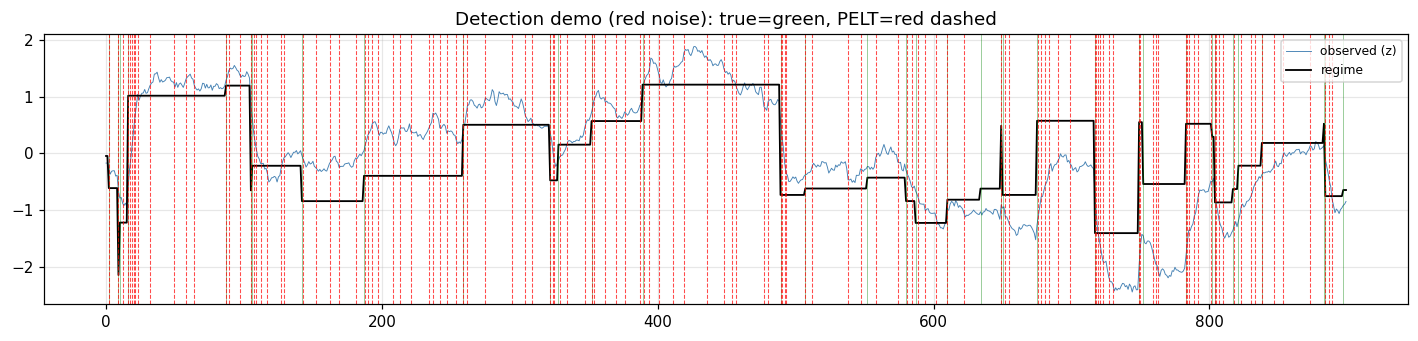

Detection quality by noise (PELT vs Chow), tol=+-5, averaged over seeds.
F1 = localisation match; Bal.Acc = imbalance-robust per-point break-vs-no-break.


,noise,n_true,PELT_f1,PELT_bal_acc,PELT_specificity,PELT_n_pred,Chow_f1,Chow_bal_acc,Chow_specificity,Chow_n_pred
0,white,392,0.468,0.637,0.926,157.000,0.503,0.652,0.897,192.333
1,pink,392,0.534,0.629,0.636,458.000,0.488,0.603,0.714,326.667
2,red,392,0.316,0.641,0.309,2047.000,0.596,0.653,0.707,366.000
3,blue,392,0.447,0.630,0.950,129.333,0.525,0.667,0.936,166.667
4,violet,392,0.442,0.625,0.957,120.000,0.535,0.671,0.939,166.667
5,el_nino,392,0.481,0.567,0.327,849.333,0.439,0.564,0.652,358.000


In [8]:
# Visual demo on one red-noise series (the hard, autocorrelated case)
x, lat, tb = generate_series("red", CFG["main_alpha"], n=900, dt=CFG["dt"],
                             T=CFG["T"], level_sigma=CFG["level_sigma"], seed=0)
xz = (x-x.mean())/x.std()
pb = pelt_breaks(xz, beta=CFG["beta"])
cb, F, fcrit = chow_scan(xz, w=18)
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(xz, lw=0.6, color="steelblue", label="observed (z)")
ax.plot((lat-lat.mean())/x.std(), lw=1.2, color="black", label="regime")
for b in tb[tb < 900]: ax.axvline(b, color="green", lw=0.5, alpha=0.5)
for b in pb[pb < 900]:  ax.axvline(b, color="red", ls="--", lw=0.7, alpha=0.7)
ax.set_title("Detection demo (red noise): true=green, PELT=red dashed"); ax.legend(loc="upper right", fontsize=8)
plt.savefig("figures/detection_demo.png", bbox_inches="tight"); plt.show()

# Per-noise detection table (averaged over seeds): F1 + Balanced Accuracy for PELT and Chow
rows = []
for noise in CFG["noises"]:
    agg = {}
    for seed in CFG["seeds"]:
        x, lat, tb = generate_series(noise, CFG["main_alpha"], n=CFG["n"], dt=CFG["dt"],
                                     T=CFG["T"], level_sigma=CFG["level_sigma"], seed=seed)
        xz = (x-x.mean())/x.std(); n = len(xz)
        pb_ = pelt_breaks(xz, CFG["beta"]); cb_ = chow_scan(xz)[0]
        dp = detection_prf(pb_, tb, CFG["det_tol"]); dpc = detection_classification(n, pb_, tb, CFG["det_tol"])
        dc = detection_prf(cb_, tb, CFG["det_tol"]); dcc = detection_classification(n, cb_, tb, CFG["det_tol"])
        for k, v in {**dp, **dpc}.items(): agg.setdefault("PELT_"+k, []).append(v)
        for k, v in {**dc, **dcc}.items(): agg.setdefault("Chow_"+k, []).append(v)
    row = {"noise": noise, "n_true": len(tb)}
    row.update({k: np.mean(v) for k, v in agg.items()})
    rows.append(row)
det_df = pd.DataFrame(rows).round(3)
det_df.to_csv("results/detection_by_noise.csv", index=False)
print("Detection quality by noise (PELT vs Chow), tol=+-5, averaged over seeds.")
print("F1 = localisation match; Bal.Acc = imbalance-robust per-point break-vs-no-break.")
det_df[["noise", "n_true", "PELT_f1", "PELT_bal_acc", "PELT_specificity", "PELT_n_pred",
        "Chow_f1", "Chow_bal_acc", "Chow_specificity", "Chow_n_pred"]]

> **Why also report Balanced Accuracy?** Breaks are rare (~1% of points), and under that imbalance F1 / PR-AUC can flatter a detector that simply *over-segments*. **Balanced Accuracy = (sensitivity + specificity)/2** penalises the false alarms an over-segmenting detector raises in the long "no-break" stretches. This is exactly visible on **red / El&nbsp;Niño**, where PELT's many spurious cuts keep recall high but drag **specificity — and therefore Balanced Accuracy — down**. (This echoes the *perils of misleading metrics* point in the group journal plan.)

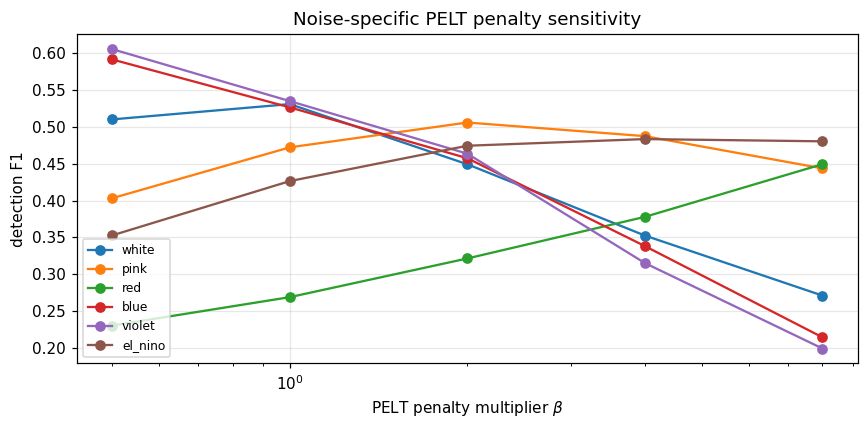

,noise,beta=0.5,beta=1.0,beta=2.0,beta=4.0,beta=8.0
0,white,0.510,0.531,0.449,0.352,0.271
1,pink,0.403,0.472,0.506,0.487,0.444
2,red,0.230,0.269,0.321,0.378,0.449
3,blue,0.592,0.527,0.457,0.338,0.214
4,violet,0.606,0.535,0.464,0.315,0.199
5,el_nino,0.353,0.426,0.474,0.483,0.480


In [9]:
# PELT penalty (beta) sensitivity  ->  noise-specific tuning, as in the coursework
betas = [0.5, 1.0, 2.0, 4.0, 8.0]
fig, ax = plt.subplots(figsize=(8, 4))
sens = []
for noise in CFG["noises"]:
    f1s = []
    for beta in betas:
        x, _, tb = generate_series(noise, CFG["main_alpha"], n=CFG["n"], dt=CFG["dt"],
                                   T=CFG["T"], level_sigma=CFG["level_sigma"], seed=0)
        xz = (x-x.mean())/x.std()
        f1s.append(detection_prf(pelt_breaks(xz, beta), tb, CFG["det_tol"])["f1"])
    sens.append([noise]+f1s)
    ax.plot(betas, f1s, marker="o", label=noise)
ax.set_xscale("log"); ax.set_xlabel("PELT penalty multiplier $\\beta$"); ax.set_ylabel("detection F1")
ax.set_title("Noise-specific PELT penalty sensitivity"); ax.legend(fontsize=8)
plt.savefig("figures/pelt_penalty_sensitivity.png", bbox_inches="tight"); plt.show()
pd.DataFrame(sens, columns=["noise"]+[f"beta={b}" for b in betas]).round(3)

### 4.4 How strong is a break? — detection power vs break strength

Detection scores only make sense once you know **how strong the breaks are**. We score each break by
its **standardised jump** — the effect size / signal-to-noise ratio:

**δ = |Δlevel| / σ_noise**

and ask how detection depends on it. The key finding: in this DGP roughly **half the breaks are weak
(δ<1)** — the jump is *smaller than the noise* — so they are physically hard to see. PELT recall rises
monotonically with δ (a **detection power curve**), and break strength is itself **measurable from the
observed series** (the local mean-jump). This reframes the modest detection numbers: the misses are
mostly genuinely-weak breaks, not a broken detector.

14184 breaks | median strength=0.97 | weak (delta<1)=51% | mean strength detected=1.56 vs missed=0.92
corr(true strength, data-estimated strength) = 0.37  -> strength is measurable from data


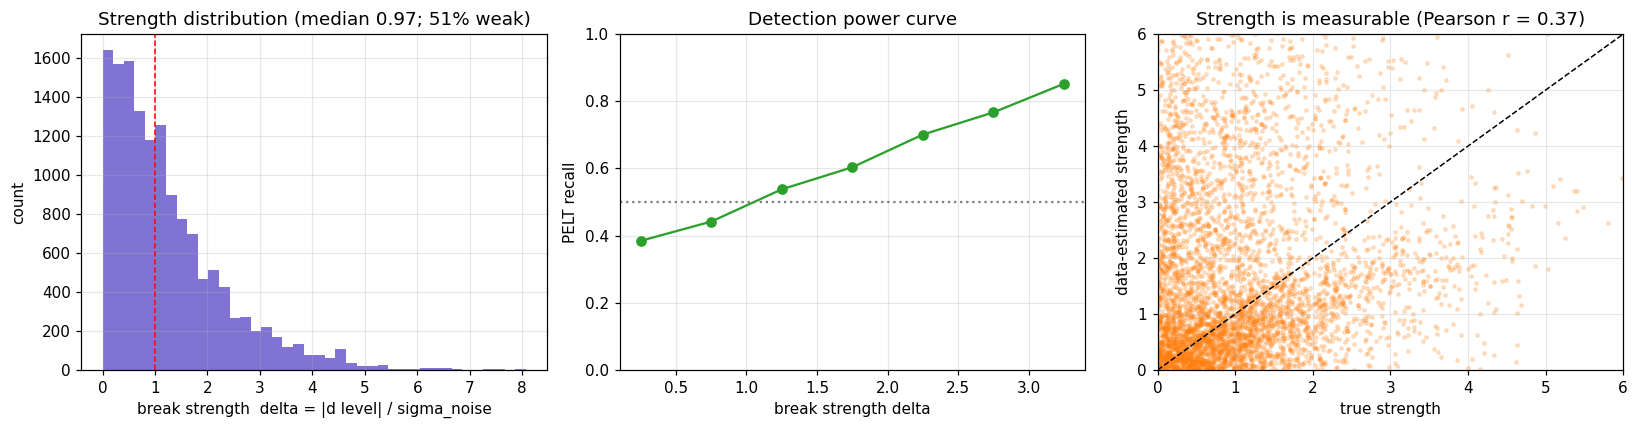

In [10]:
# break strength delta = |d level| / sigma_noise ; does detection depend on it?
C = CFG; delta = []; det = []
for noise in C["noises"]:
    for alpha in (1.0, 2.0):
        for seed in C["seeds"]:
            x, lat, tb = generate_series(noise, alpha, n=C["n"], dt=C["dt"], T=C["T"],
                                         level_sigma=C["level_sigma"], seed=seed)
            xz = (x-x.mean())/x.std(); pb = pelt_breaks(xz, C["beta"])
            for b in tb:
                if b < 1: continue
                delta.append(abs(lat[b]-lat[b-1])/alpha)
                det.append(bool(np.any(np.abs(pb-b) <= C["det_tol"])))
delta = np.array(delta); det = np.array(det)
edges = [0, 0.5, 1, 1.5, 2, 2.5, 3, 10]; cen = []; rec = []; cnt = []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (delta >= lo) & (delta < hi)
    if m.sum(): cen.append((lo+min(hi, 3.5))/2); rec.append(det[m].mean()); cnt.append(int(m.sum()))
pd.DataFrame({"delta_from": edges[:len(rec)], "recall": np.round(rec, 3), "n": cnt}).to_csv(
    "results/break_strength_powercurve.csv", index=False)
print(f"{len(delta)} breaks | median strength={np.median(delta):.2f} | weak (delta<1)={np.mean(delta<1):.0%} "
      f"| mean strength detected={delta[det].mean():.2f} vs missed={delta[~det].mean():.2f}")

# is break strength measurable from the observed series? (local mean jump)
W = 8; true_d = []; est_d = []
for noise in ("white", "red", "el_nino"):
    for alpha in (1.0, 2.0):
        for seed in C["seeds"]:
            x, lat, tb = generate_series(noise, alpha, n=C["n"], dt=C["dt"], T=C["T"],
                                         level_sigma=C["level_sigma"], seed=seed)
            xz = (x-x.mean())/x.std(); sg = estimate_sigma(xz)
            for b in tb:
                b = int(b)
                if b-W < 0 or b+W >= len(xz): continue
                true_d.append(abs(lat[b]-lat[b-1])/alpha)
                est_d.append(abs(xz[b:b+W].mean()-xz[b-W:b].mean())/max(sg, 1e-6))
true_d = np.array(true_d); est_d = np.array(est_d); rr = stats.pearsonr(true_d, est_d)[0]
print(f"corr(true strength, data-estimated strength) = {rr:.2f}  -> strength is measurable from data")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(delta, bins=40, color="slateblue", alpha=.85); ax[0].axvline(1, color="red", ls="--", lw=1)
ax[0].set_xlabel("break strength  delta = |d level| / sigma_noise"); ax[0].set_ylabel("count")
ax[0].set_title(f"Strength distribution (median {np.median(delta):.2f}; {np.mean(delta<1):.0%} weak)")
ax[1].plot(cen, rec, "o-", color="tab:green"); ax[1].axhline(0.5, color="grey", ls=":")
ax[1].set_xlabel("break strength delta"); ax[1].set_ylabel("PELT recall"); ax[1].set_ylim(0, 1)
ax[1].set_title("Detection power curve")
lim = min(float(true_d.max()), 6.0); ax[2].scatter(true_d, est_d, s=5, alpha=.2, color="tab:orange")
ax[2].plot([0, lim], [0, lim], "k--", lw=1); ax[2].set_xlim(0, lim); ax[2].set_ylim(0, lim)
ax[2].set_xlabel("true strength"); ax[2].set_ylabel("data-estimated strength")
ax[2].set_title(f"Strength is measurable (Pearson r = {rr:.2f})")
plt.savefig("figures/break_strength.png", bbox_inches="tight"); plt.show()

## 5 · Forecasting models: plain GRU and the hybrid PELT-GRU

**Task.** From a window $[x_{t-L},\dots,x_{t-1}]$ predict $x_{t+h-1}$ (direct $h$-step forecast). The series is standardised with **training-set** statistics only; errors are reported back in the **original units**.

**Plain GRU.** One GRU layer + linear head. A fair, well-trained baseline.

**Hybrid GRU.** The same GRU, but the linear head also receives **PELT structural features** for the target index: the segment mean and std (the regime level/scale), the relative position in the segment, and the (scaled) distances to the previous/next break. This is the *"breakpoint information as a feature"* hybrid.

> Because PELT runs on the whole series, the segment features encode regime membership of the target — this is the **offline / accurate-detection** setting whose value we are measuring. The causal counterpart is studied in Part&nbsp;7.

### 5.1 Windowing and structural features

In [11]:
def make_windows(x, L, h):
    idx = np.arange(L, len(x)-h+1)
    X = np.stack([x[t-L:t] for t in idx])[..., None].astype(np.float32)
    tgt = idx + h - 1
    return X, x[tgt].astype(np.float32), tgt

def segment_features(x, breaks):
    """Per-timestep features induced by an (offline) PELT segmentation."""
    n = len(x); bounds = [0] + list(map(int, breaks)) + [n]
    sm = np.zeros(n); ss = np.zeros(n); sp = np.zeros(n); dprev = np.zeros(n); dnext = np.zeros(n)
    for a, b in zip(bounds[:-1], bounds[1:]):
        idx = np.arange(a, b)
        sm[a:b] = x[a:b].mean(); ss[a:b] = x[a:b].std()
        sp[a:b] = (idx-a)/max(1, b-a); dprev[a:b] = idx-a; dnext[a:b] = (b-1)-idx
    return sm, ss, sp, dprev, dnext

def build_offline_features(xz, breaks, tgt, L):
    sm, ss, sp, dprev, dnext = segment_features(xz, breaks)
    return np.stack([sm[tgt], ss[tgt], sp[tgt], dprev[tgt]/L, dnext[tgt]/L], axis=1).astype(np.float32)

### 5.2 GRU architecture and training

In [12]:
class GRUForecaster(nn.Module):
    def __init__(self, hidden=64, n_static=0):
        super().__init__()
        self.gru = nn.GRU(1, hidden, batch_first=True)
        self.n_static = n_static
        self.head = nn.Linear(hidden + n_static, 1)
    def forward(self, x_seq, x_static=None):
        _, h = self.gru(x_seq); h = h[-1]
        if self.n_static > 0:
            h = torch.cat([h, x_static], dim=1)
        return self.head(h).squeeze(-1)

def train_gru(Xtr, Ytr, Xva, Yva, Str=None, Sva=None, hidden=64,
              epochs=12, lr=1e-3, batch=128, seed=0):
    set_seed(seed)
    n_static = 0 if Str is None else Str.shape[1]
    model = GRUForecaster(hidden, n_static).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr); lossf = nn.MSELoss()
    Xtr_t = torch.tensor(Xtr, device=DEVICE); Ytr_t = torch.tensor(Ytr, device=DEVICE)
    Str_t = None if Str is None else torch.tensor(Str, device=DEVICE)
    best, best_va, N = None, np.inf, len(Xtr)
    for ep in range(epochs):
        model.train(); perm = np.random.permutation(N)
        for i in range(0, N, batch):
            j = perm[i:i+batch]; opt.zero_grad()
            s = None if Str_t is None else Str_t[j]
            loss = lossf(model(Xtr_t[j], s), Ytr_t[j]); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            sv = None if Sva is None else torch.tensor(Sva, device=DEVICE)
            va = float(((model(torch.tensor(Xva, device=DEVICE), sv).cpu().numpy() - Yva)**2).mean())
        if va < best_va:
            best_va = va; best = {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best)
    return model

def predict(model, X, S=None):
    model.eval()
    with torch.no_grad():
        s = None if S is None else torch.tensor(S, device=DEVICE)
        return model(torch.tensor(X, device=DEVICE), s).cpu().numpy()

### 5.3 Metrics — forecasting and break-aware residual scoring

In [13]:
def rmse(a, b): return float(np.sqrt(np.mean((a-b)**2)))
def mae(a, b):  return float(np.mean(np.abs(a-b)))

def break_label(tgt_idx, true_breaks, tol=3):
    if len(true_breaks) == 0: return np.zeros(len(tgt_idx), dtype=int)
    d = np.abs(tgt_idx[:, None] - np.array(true_breaks)[None, :]).min(axis=1)
    return (d <= tol).astype(int)

def residual_metrics(resid, labels):
    """Break-aware classification quality of |residual| vs true-break-adjacency:
    PR-AUC / ROC-AUC (threshold-free) + Precision / Recall / F1 at the best-F1 threshold."""
    score = np.abs(resid)
    if not (0 < labels.sum() < len(labels)):
        return dict(precision=np.nan, recall=np.nan, f1=np.nan, pr_auc=np.nan, roc_auc=np.nan)
    bf1, bp, br = 0.0, 0.0, 0.0
    for q in np.linspace(0.80, 0.99, 12):
        pred = (score >= np.quantile(score, q)).astype(int)
        f1v = f1_score(labels, pred, zero_division=0)
        if f1v > bf1:
            bf1 = f1v
            bp = precision_score(labels, pred, zero_division=0)
            br = recall_score(labels, pred, zero_division=0)
    return dict(precision=bp, recall=br, f1=bf1,
                pr_auc=average_precision_score(labels, score),
                roc_auc=roc_auc_score(labels, score))

def run_pair(noise, alpha, h, seed, return_arrays=False):
    """Train plain + hybrid GRU on one series; return a dict of metrics."""
    C = CFG
    x, lat, tb = generate_series(noise, alpha, n=C["n"], dt=C["dt"], T=C["T"],
                                 level_sigma=C["level_sigma"], seed=seed)
    n = len(x); a, b = int(0.6*n), int(0.8*n)
    mu, sd = x[:a].mean(), x[:a].std(); xz = (x-mu)/sd
    breaks = pelt_breaks(xz, C["beta"])
    X, Y, tgt = make_windows(xz, C["L"], h)
    S = build_offline_features(xz, breaks, tgt, C["L"])
    tr = tgt < a; va = (tgt >= a) & (tgt < b); te = tgt >= b
    mp = train_gru(X[tr], Y[tr], X[va], Y[va], hidden=C["hidden"], epochs=C["epochs"],
                   lr=C["lr"], batch=C["batch"], seed=seed)
    mh = train_gru(X[tr], Y[tr], X[va], Y[va], S[tr], S[va], hidden=C["hidden"],
                   epochs=C["epochs"], lr=C["lr"], batch=C["batch"], seed=seed)
    pp, ph = predict(mp, X[te]), predict(mh, X[te], S[te])
    yte = Y[te]*sd + mu; pp_o, ph_o = pp*sd+mu, ph*sd+mu
    lab = break_label(tgt[te], tb, C["tol"])
    rp, rh = residual_metrics(pp-Y[te], lab), residual_metrics(ph-Y[te], lab)
    out = dict(noise=noise, alpha=round(float(alpha), 3), h=h, seed=seed,
               rmse_plain=rmse(pp_o, yte), rmse_hybrid=rmse(ph_o, yte),
               mae_plain=mae(pp_o, yte), mae_hybrid=mae(ph_o, yte),
               pr_plain=rp["pr_auc"], pr_hybrid=rh["pr_auc"],
               roc_plain=rp["roc_auc"], roc_hybrid=rh["roc_auc"],
               f1_plain=rp["f1"], f1_hybrid=rh["f1"],
               prec_plain=rp["precision"], prec_hybrid=rh["precision"],
               rec_plain=rp["recall"], rec_hybrid=rh["recall"])
    if return_arrays:
        out["arrays"] = dict(tgt=tgt[te], y=yte, pp=pp_o, ph=ph_o, tb=tb)
    return out

def aggregate(noise, alpha, h):
    res = [run_pair(noise, alpha, h, s) for s in CFG["seeds"]]
    keys = [k for k in res[0] if k not in ("noise", "seed")]
    out = {"noise": noise}
    for k in keys: out[k] = np.nanmean([r[k] for r in res])
    return out

def run_delevel(noise, alpha, h, seed):
    """plain vs feature-hybrid vs DE-LEVELLED hybrid. The de-levelled hybrid subtracts the PELT
    segment mean, forecasts only the residual x - seg_mean, then adds the target's segment mean
    back. Both hybrids use the SAME offline PELT segmentation (fair architectural comparison)."""
    C = CFG
    x, lat, tb = generate_series(noise, alpha, n=C["n"], dt=C["dt"], T=C["T"],
                                 level_sigma=C["level_sigma"], seed=seed)
    n = len(x); a, b = int(0.6*n), int(0.8*n); mu, sd = x[:a].mean(), x[:a].std(); xz = (x-mu)/sd
    breaks = pelt_breaks(xz, C["beta"]); sm = segment_features(xz, breaks)[0]; resid = xz - sm
    X, Y, tgt = make_windows(xz, C["L"], h); Xr = make_windows(resid, C["L"], h)[0]
    S = build_offline_features(xz, breaks, tgt, C["L"]); Yr = resid[tgt].astype(np.float32)
    tr = tgt < a; va = (tgt >= a) & (tgt < b); te = tgt >= b; yte = Y[te]*sd + mu
    mp = train_gru(X[tr], Y[tr], X[va], Y[va], hidden=C["hidden"], epochs=C["epochs"], seed=seed)
    mf = train_gru(X[tr], Y[tr], X[va], Y[va], S[tr], S[va], hidden=C["hidden"], epochs=C["epochs"], seed=seed)
    md = train_gru(Xr[tr], Yr[tr], Xr[va], Yr[va], hidden=C["hidden"], epochs=C["epochs"], seed=seed)
    return (rmse(predict(mp, X[te])*sd+mu, yte),
            rmse(predict(mf, X[te], S[te])*sd+mu, yte),
            rmse((predict(md, Xr[te]) + sm[tgt][te])*sd+mu, yte))

### 5.4 Break detection — classical vs modern ML (the GRU residual monitor)

The assignment asks for **both classical and modern-ML break detection**. The GRU gives us a *modern* detector for free: train a **one-step-ahead** GRU and treat a spike in its **prediction residual** as a change signal — a regime switch makes the next value locally unpredictable. We score PELT, Chow, and this **GRU residual monitor** by **Balanced Accuracy** (the imbalance-robust metric from 4.3) on the same series.

  white done
  pink done
  red done
  blue done
  violet done
  el_nino done


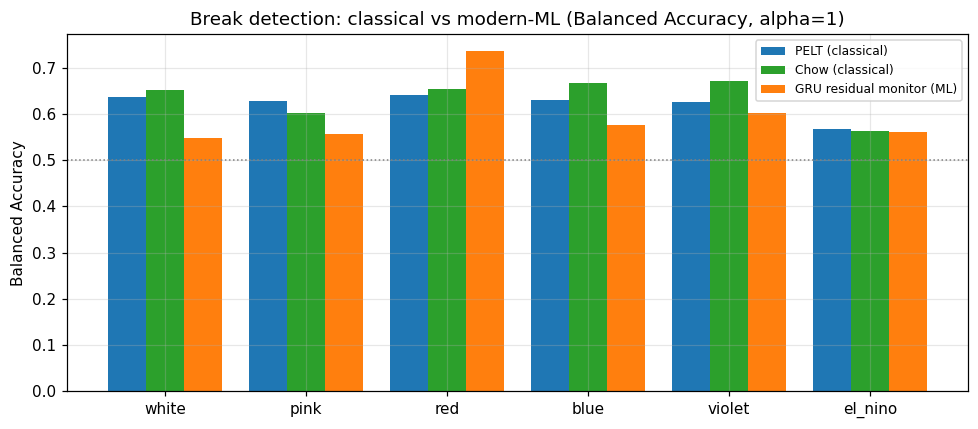

,noise,PELT_BA,Chow_BA,GRUmon_BA,PELT_F1,Chow_F1,GRUmon_F1
0,white,0.637,0.652,0.547,0.468,0.503,0.371
1,pink,0.629,0.603,0.556,0.534,0.488,0.382
2,red,0.641,0.653,0.736,0.316,0.596,0.608
3,blue,0.630,0.667,0.577,0.447,0.525,0.421
4,violet,0.625,0.671,0.602,0.442,0.535,0.474
5,el_nino,0.567,0.564,0.561,0.481,0.439,0.396


In [14]:
def gru_monitor_breaks(xz, L, seed, q=0.96):
    """Modern-ML detector: one-step-ahead GRU; flag residual-spike peaks as breaks."""
    X, Y, tgt = make_windows(xz, L, 1)
    a, b = int(0.6*len(xz)), int(0.8*len(xz))
    tr = tgt < a; va = (tgt >= a) & (tgt < b)
    m = train_gru(X[tr], Y[tr], X[va], Y[va], hidden=CFG["hidden"], epochs=CFG["epochs"], seed=seed)
    resid = np.abs(predict(m, X) - Y)
    peaks, _ = find_peaks(resid, height=np.quantile(resid, q), distance=max(2, L//2))
    return tgt[peaks]

C = CFG; rows = []
for noise in C["noises"]:
    acc = {k: [] for k in ["PELT_BA","Chow_BA","GRUmon_BA","PELT_F1","Chow_F1","GRUmon_F1"]}
    for seed in C["seeds"]:
        x, lat, tb = generate_series(noise, C["main_alpha"], n=C["n"], dt=C["dt"], T=C["T"],
                                     level_sigma=C["level_sigma"], seed=seed)
        xz = (x-x.mean())/x.std(); n = len(xz)
        pbk = pelt_breaks(xz, C["beta"]); cbk = chow_scan(xz)[0]; gbk = gru_monitor_breaks(xz, C["L"], seed)
        acc["PELT_BA"].append(detection_classification(n, pbk, tb, C["det_tol"])["bal_acc"])
        acc["Chow_BA"].append(detection_classification(n, cbk, tb, C["det_tol"])["bal_acc"])
        acc["GRUmon_BA"].append(detection_classification(n, gbk, tb, C["det_tol"])["bal_acc"])
        acc["PELT_F1"].append(detection_prf(pbk, tb, C["det_tol"])["f1"])
        acc["Chow_F1"].append(detection_prf(cbk, tb, C["det_tol"])["f1"])
        acc["GRUmon_F1"].append(detection_prf(gbk, tb, C["det_tol"])["f1"])
    rows.append(dict(noise=noise, **{k: np.mean(v) for k, v in acc.items()}))
    print(f"  {noise} done")
detml = pd.DataFrame(rows).round(3); detml.to_csv("results/detection_classical_vs_ml.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4)); xp = np.arange(len(detml)); w = 0.27
ax.bar(xp-w, detml["PELT_BA"], w, label="PELT (classical)", color="tab:blue")
ax.bar(xp,   detml["Chow_BA"], w, label="Chow (classical)", color="tab:green")
ax.bar(xp+w, detml["GRUmon_BA"], w, label="GRU residual monitor (ML)", color="tab:orange")
ax.axhline(0.5, color="grey", ls=":", lw=1); ax.set_xticks(xp); ax.set_xticklabels(detml["noise"])
ax.set_ylabel("Balanced Accuracy"); ax.set_title("Break detection: classical vs modern-ML (Balanced Accuracy, alpha=1)")
ax.legend(fontsize=8); plt.savefig("figures/detection_classical_vs_ml.png", bbox_inches="tight"); plt.show()
detml

## 6 · Experimental results

### 6.1 Single-series demonstration — where the hybrid wins

The plain GRU lags at every regime change (it cannot see the switch coming through the $h$-step gap); the hybrid, holding the segment statistics, snaps to the correct level. Watch the residuals around the red break lines.

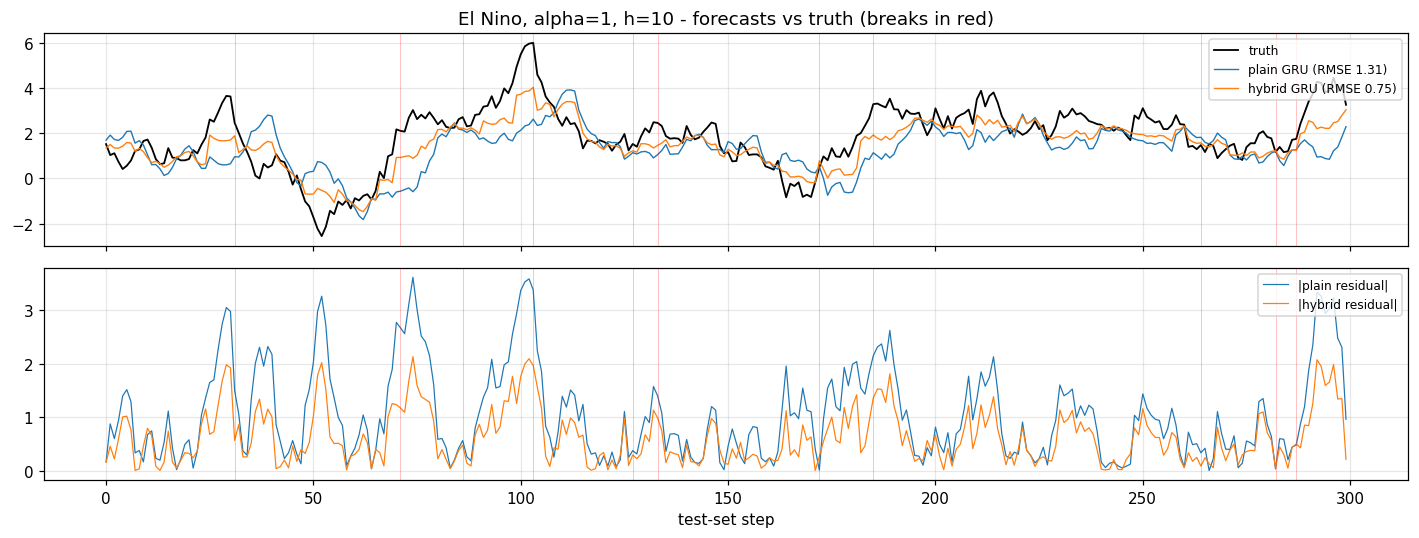

In [15]:
demo = run_pair("el_nino", CFG["main_alpha"], CFG["main_h"], seed=0, return_arrays=True)
A = demo["arrays"]; sl = slice(0, 300)
fig, ax = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
ax[0].plot(A["y"][sl], color="black", lw=1.2, label="truth")
ax[0].plot(A["pp"][sl], color="tab:blue", lw=0.9, label=f"plain GRU (RMSE {demo['rmse_plain']:.2f})")
ax[0].plot(A["ph"][sl], color="tab:orange", lw=0.9, label=f"hybrid GRU (RMSE {demo['rmse_hybrid']:.2f})")
tb_loc = A["tb"][(A["tb"] >= A["tgt"][sl][0]) & (A["tb"] <= A["tgt"][sl][-1])]
for b in tb_loc: ax[0].axvline(b - A["tgt"][0], color="red", lw=0.4, alpha=0.4)
ax[0].legend(loc="upper right", fontsize=8); ax[0].set_title("El Nino, alpha=1, h=10 - forecasts vs truth (breaks in red)")
ax[1].plot(np.abs(A["y"]-A["pp"])[sl], color="tab:blue", lw=0.8, label="|plain residual|")
ax[1].plot(np.abs(A["y"]-A["ph"])[sl], color="tab:orange", lw=0.8, label="|hybrid residual|")
for b in tb_loc: ax[1].axvline(b - A["tgt"][0], color="red", lw=0.4, alpha=0.4)
ax[1].legend(loc="upper right", fontsize=8); ax[1].set_xlabel("test-set step")
plt.savefig("figures/single_series_demo.png", bbox_inches="tight"); plt.show()

**Forecast galleries.** The same view for **all six noise types**, and for **red noise across the four
horizons** — so the per-noise RMSE differences and the "longer $h$ → smoother, lags more" effect are
visible, not just tabulated.

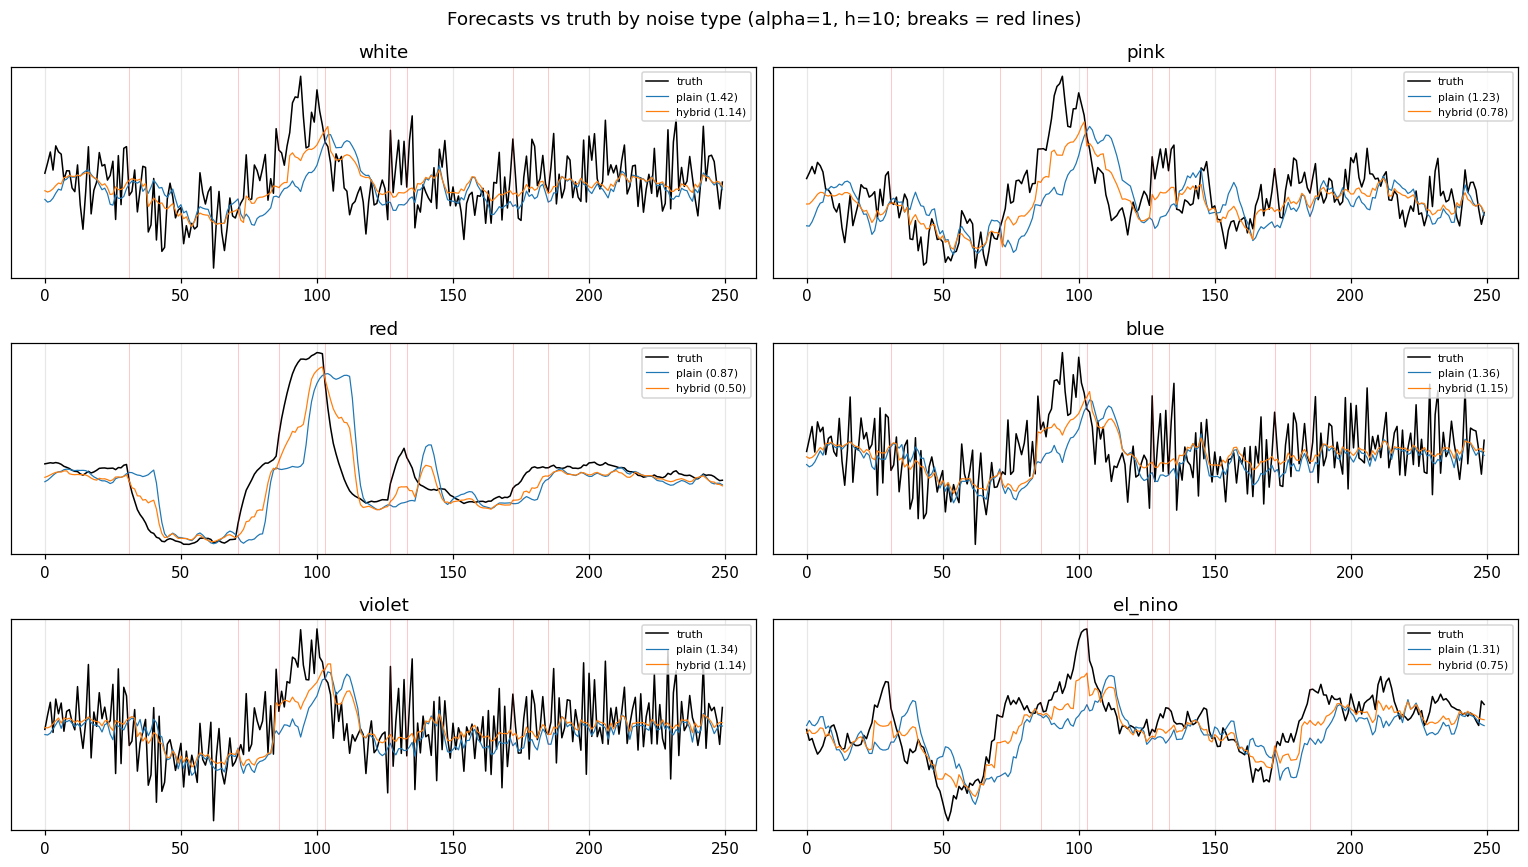

In [16]:
# gallery: plain vs hybrid forecast for every noise type (h=10)
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
for ax, noise in zip(axes.ravel(), CFG["noises"]):
    d = run_pair(noise, CFG["main_alpha"], CFG["main_h"], seed=0, return_arrays=True); A = d["arrays"]; sl = slice(0, 250)
    ax.plot(A["y"][sl], color="black", lw=1.0, label="truth")
    ax.plot(A["pp"][sl], color="tab:blue", lw=0.8, label=f"plain ({d['rmse_plain']:.2f})")
    ax.plot(A["ph"][sl], color="tab:orange", lw=0.8, label=f"hybrid ({d['rmse_hybrid']:.2f})")
    for b in A["tb"][(A["tb"] >= A["tgt"][sl][0]) & (A["tb"] <= A["tgt"][sl][-1])]:
        ax.axvline(b - A["tgt"][0], color="red", lw=0.4, alpha=0.35)
    ax.set_title(noise); ax.set_yticks([]); ax.legend(fontsize=7, loc="upper right")
fig.suptitle("Forecasts vs truth by noise type (alpha=1, h=10; breaks = red lines)")
plt.savefig("figures/pred_gallery_by_noise.png", bbox_inches="tight"); plt.show()

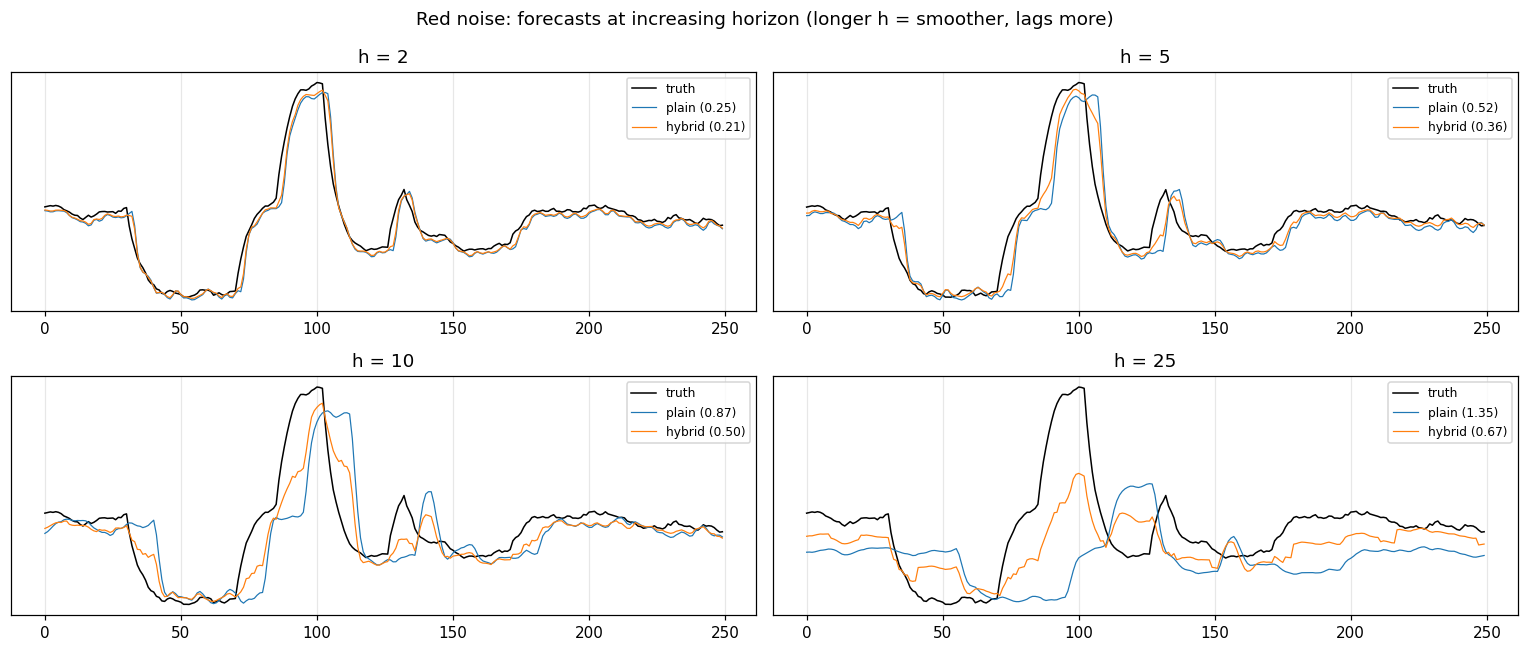

In [17]:
# red noise: forecasts at increasing horizon
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
for ax, h in zip(axes.ravel(), CFG["horizons"]):
    d = run_pair("red", CFG["main_alpha"], h, seed=0, return_arrays=True); A = d["arrays"]; sl = slice(0, 250)
    ax.plot(A["y"][sl], color="black", lw=1.0, label="truth")
    ax.plot(A["pp"][sl], color="tab:blue", lw=0.8, label=f"plain ({d['rmse_plain']:.2f})")
    ax.plot(A["ph"][sl], color="tab:orange", lw=0.8, label=f"hybrid ({d['rmse_hybrid']:.2f})")
    ax.set_title(f"h = {h}"); ax.set_yticks([]); ax.legend(fontsize=8, loc="upper right")
fig.suptitle("Red noise: forecasts at increasing horizon (longer h = smoother, lags more)")
plt.savefig("figures/pred_by_horizon.png", bbox_inches="tight"); plt.show()

### 6.2 Per-noise comparison (main operating point: $\alpha=1$, $h=10$)

This is the central results table (mirrors the coursework's Table&nbsp;1/Table&nbsp;3). To make it
**rigorous**, it is run over **multiple random seeds** (10 in the full run, `n_seeds_sig`), reported
as **mean ± std**, and the hybrid's improvement is tested with a **one-sided paired Wilcoxon
signed-rank test** per noise (and pooled). A small *p* means the gain is **consistent across data
realisations**, not a lucky seed.

In [18]:
from scipy.stats import wilcoxon
C = CFG; seeds_sig = list(range(C["n_seeds_sig"]))
t0 = time.time(); rows = []; pooled_p, pooled_h = [], []
for noise in C["noises"]:
    rp, rh, mp, mh, prp, prh = [], [], [], [], [], []
    for seed in seeds_sig:
        r = run_pair(noise, C["main_alpha"], C["main_h"], seed)
        rp.append(r["rmse_plain"]); rh.append(r["rmse_hybrid"])
        mp.append(r["mae_plain"]);  mh.append(r["mae_hybrid"])
        prp.append(r["pr_plain"]);  prh.append(r["pr_hybrid"])
    pooled_p += rp; pooled_h += rh
    try:
        _, pval = wilcoxon(rp, rh, alternative="greater")   # H1: plain RMSE > hybrid RMSE
    except ValueError:
        pval = np.nan
    rows.append(dict(noise=noise,
        rmse_plain=np.mean(rp), rmse_plain_sd=np.std(rp),
        rmse_hybrid=np.mean(rh), rmse_hybrid_sd=np.std(rh),
        mae_plain=np.mean(mp), mae_hybrid=np.mean(mh),
        pr_plain=np.mean(prp), pr_hybrid=np.mean(prh),
        gain_pct=100*(np.mean(rp)-np.mean(rh))/np.mean(rp), wilcoxon_p=pval))
    print(f"  {noise:8s} done  ({time.time()-t0:5.1f}s)")
pernoise = pd.DataFrame(rows).round(4)
pernoise.to_csv("results/per_noise_main.csv", index=False)
_, p_all = wilcoxon(pooled_p, pooled_h, alternative="greater")
print(f"\nPooled across all noises x seeds (n={len(pooled_p)}): hybrid < plain, Wilcoxon p = {p_all:.2e}")
pernoise[["noise", "rmse_plain", "rmse_plain_sd", "rmse_hybrid", "rmse_hybrid_sd", "gain_pct", "wilcoxon_p"]]

  white    done  ( 53.3s)
  pink     done  (108.7s)
  red      done  (164.0s)
  blue     done  (218.4s)
  violet   done  (273.7s)
  el_nino  done  (328.2s)

Pooled across all noises x seeds (n=60): hybrid < plain, Wilcoxon p = 8.15e-12


,noise,rmse_plain,rmse_plain_sd,rmse_hybrid,rmse_hybrid_sd,gain_pct,wilcoxon_p
0,white,1.3932,0.0723,1.1531,0.0358,17.2329,0.001
1,pink,1.2092,0.0754,0.8140,0.0619,32.6832,0.001
2,red,0.8698,0.1036,0.5502,0.0813,36.7497,0.001
3,blue,1.3561,0.0687,1.1699,0.0308,13.7358,0.001
4,violet,1.3318,0.0690,1.1658,0.0316,12.4654,0.001
5,el_nino,1.2705,0.0885,0.7716,0.0798,39.2679,0.001


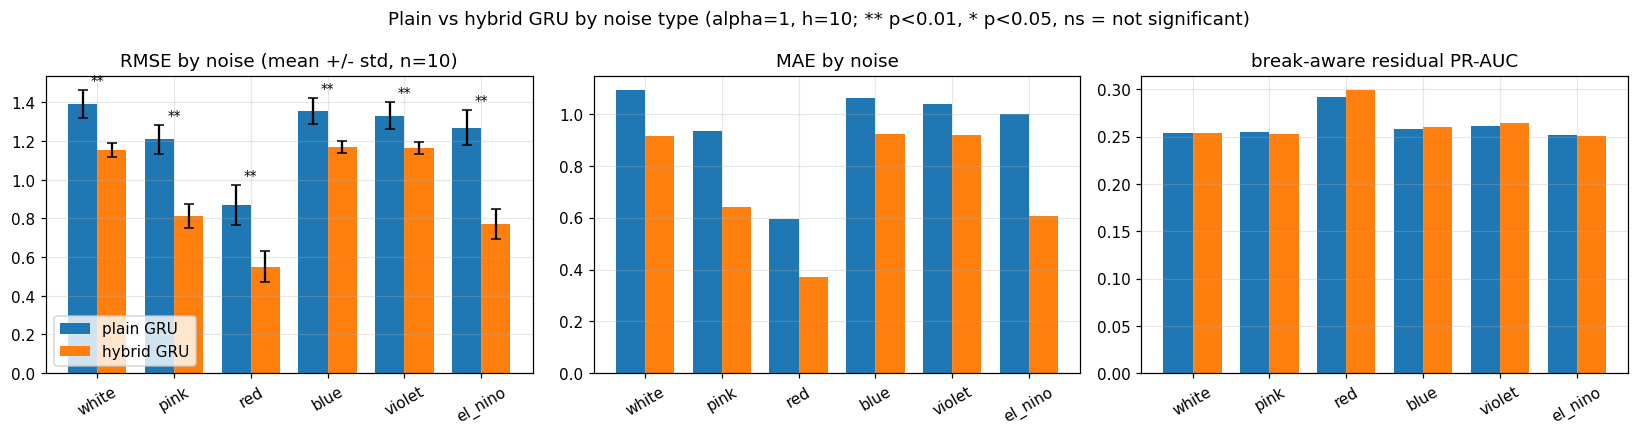

In [19]:
# Error-bar comparison by noise (mean +/- std) with significance stars on RMSE
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
xpos = np.arange(len(CFG["noises"])); wbar = 0.38
ax[0].bar(xpos-wbar/2, pernoise["rmse_plain"], wbar, yerr=pernoise["rmse_plain_sd"],
          capsize=3, label="plain GRU", color="tab:blue")
ax[0].bar(xpos+wbar/2, pernoise["rmse_hybrid"], wbar, yerr=pernoise["rmse_hybrid_sd"],
          capsize=3, label="hybrid GRU", color="tab:orange")
for i, p in enumerate(pernoise["wilcoxon_p"]):
    star = "**" if p < 0.01 else ("*" if p < 0.05 else "ns")
    top = max(pernoise["rmse_plain"][i], pernoise["rmse_hybrid"][i]) + pernoise["rmse_plain_sd"][i] + 0.03
    ax[0].text(i, top, star, ha="center", fontsize=9)
ax[0].set_xticks(xpos); ax[0].set_xticklabels(pernoise["noise"], rotation=30)
ax[0].set_title(f"RMSE by noise (mean +/- std, n={CFG['n_seeds_sig']})"); ax[0].legend()
ax[1].bar(xpos-wbar/2, pernoise["mae_plain"], wbar, label="plain", color="tab:blue")
ax[1].bar(xpos+wbar/2, pernoise["mae_hybrid"], wbar, label="hybrid", color="tab:orange")
ax[1].set_xticks(xpos); ax[1].set_xticklabels(pernoise["noise"], rotation=30); ax[1].set_title("MAE by noise")
ax[2].bar(xpos-wbar/2, pernoise["pr_plain"], wbar, label="plain", color="tab:blue")
ax[2].bar(xpos+wbar/2, pernoise["pr_hybrid"], wbar, label="hybrid", color="tab:orange")
ax[2].set_xticks(xpos); ax[2].set_xticklabels(pernoise["noise"], rotation=30); ax[2].set_title("break-aware residual PR-AUC")
fig.suptitle("Plain vs hybrid GRU by noise type (alpha=1, h=10; ** p<0.01, * p<0.05, ns = not significant)")
plt.savefig("figures/per_noise_bars.png", bbox_inches="tight"); plt.show()

### 6.3 Effect of the forecast horizon $h$

The value of explicit break information **grows with the horizon**: the longer the lead time, the more likely a regime switch falls inside it, and the more the plain GRU's blindness costs. (Averaged over a representative subset of noises to keep runtime sensible.)

  h=2 done
  h=5 done
  h=10 done
  h=25 done


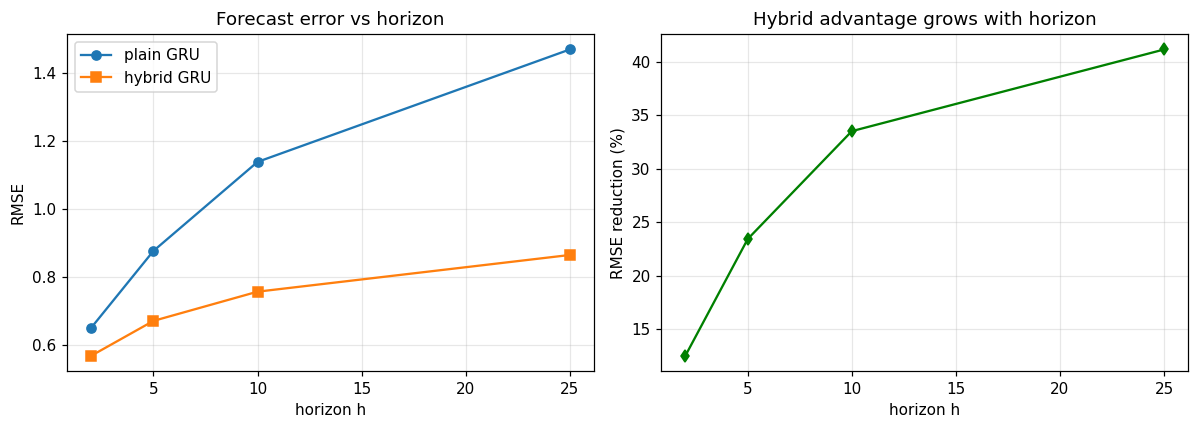

,h,rmse_plain,rmse_hybrid,pr_plain,pr_hybrid,rmse_gain_%
0,2,0.650,0.568,0.418,0.408,12.515
1,5,0.877,0.671,0.345,0.344,23.442
2,10,1.139,0.757,0.283,0.283,33.522
3,25,1.470,0.865,0.267,0.267,41.157


In [20]:
hz_noises = ["white", "red", "el_nino"]
rows = []
for h in CFG["horizons"]:
    accs = [aggregate(n, CFG["main_alpha"], h) for n in hz_noises]
    rows.append(dict(h=h,
        rmse_plain=np.mean([a["rmse_plain"] for a in accs]),
        rmse_hybrid=np.mean([a["rmse_hybrid"] for a in accs]),
        pr_plain=np.mean([a["pr_plain"] for a in accs]),
        pr_hybrid=np.mean([a["pr_hybrid"] for a in accs])))
    print(f"  h={h} done")
hz = pd.DataFrame(rows); hz["rmse_gain_%"] = 100*(hz["rmse_plain"]-hz["rmse_hybrid"])/hz["rmse_plain"]
hz = hz.round(3); hz.to_csv("results/horizon_sweep.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hz["h"], hz["rmse_plain"], "o-", label="plain GRU")
ax[0].plot(hz["h"], hz["rmse_hybrid"], "s-", label="hybrid GRU")
ax[0].set_xlabel("horizon h"); ax[0].set_ylabel("RMSE"); ax[0].set_title("Forecast error vs horizon"); ax[0].legend()
ax[1].plot(hz["h"], hz["rmse_gain_%"], "d-", color="green")
ax[1].set_xlabel("horizon h"); ax[1].set_ylabel("RMSE reduction (%)"); ax[1].set_title("Hybrid advantage grows with horizon")
plt.savefig("figures/horizon_sweep.png", bbox_inches="tight"); plt.show()
hz

### 6.4 Noise-amplitude ($\alpha$) sensitivity

The hybrid advantage is largest at moderate noise and shrinks as $\alpha$ grows: once the irreducible noise floor dominates the variance, *no* amount of structural information can help. An honest, important caveat.

  alpha=1.00 done
  alpha=2.00 done
  alpha=3.14 done


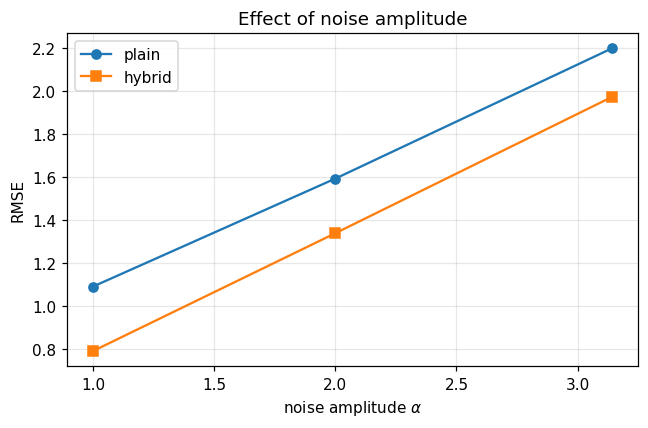

,alpha,rmse_plain,rmse_hybrid,rmse_gain_%
0,1.000,1.092,0.792,27.484
1,2.000,1.594,1.340,15.929
2,3.142,2.200,1.974,10.273


In [21]:
al_noises = ["white", "red"]
rows = []
for alpha in CFG["alphas"]:
    accs = [aggregate(n, alpha, CFG["main_h"]) for n in al_noises]
    rows.append(dict(alpha=round(float(alpha), 3),
        rmse_plain=np.mean([a["rmse_plain"] for a in accs]),
        rmse_hybrid=np.mean([a["rmse_hybrid"] for a in accs])))
    print(f"  alpha={alpha:.2f} done")
al = pd.DataFrame(rows); al["rmse_gain_%"] = 100*(al["rmse_plain"]-al["rmse_hybrid"])/al["rmse_plain"]
al = al.round(3); al.to_csv("results/alpha_sensitivity.csv", index=False)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(al["alpha"], al["rmse_plain"], "o-", label="plain")
ax.plot(al["alpha"], al["rmse_hybrid"], "s-", label="hybrid")
ax.set_xlabel("noise amplitude $\\alpha$"); ax.set_ylabel("RMSE"); ax.set_title("Effect of noise amplitude"); ax.legend()
plt.savefig("figures/alpha_sensitivity.png", bbox_inches="tight"); plt.show()
al

### 6.5 Global comparison — is the GRU the right backbone?

We place the two GRUs next to a **naive persistence** baseline and a **gradient-boosting** forecaster (flattened-window features). This satisfies the assignment's model survey and shows the hybrid framework is model-agnostic while the GRU is the strongest standard backbone.

> A *boosting hybrid* is deliberately **not** reported as a result: a tree can copy the offline segment mean almost verbatim, collapsing the error to a value that reflects information leakage, not skill — a vivid reminder of why the causal analysis in Part&nbsp;7 matters.

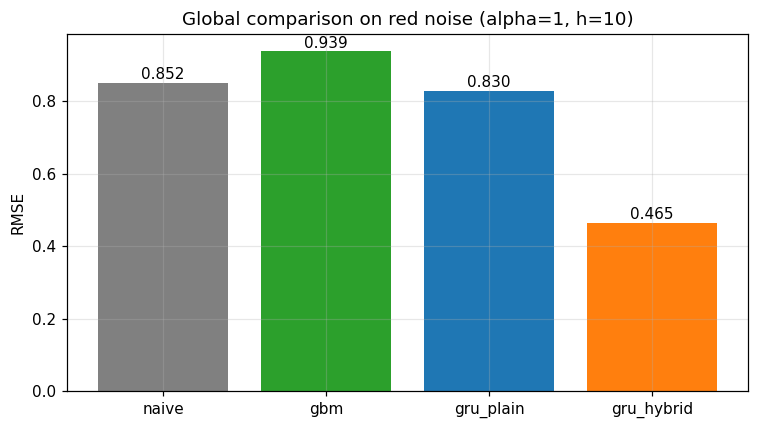

,RMSE
naive,0.852
gbm,0.939
gru_plain,0.830
gru_hybrid,0.465


In [22]:
C = CFG; noise = "red"; rows = []
for seed in C["seeds"]:
    x, lat, tb = generate_series(noise, C["main_alpha"], n=C["n"], dt=C["dt"], T=C["T"],
                                 level_sigma=C["level_sigma"], seed=seed)
    n = len(x); a, b = int(0.6*n), int(0.8*n); mu, sd = x[:a].mean(), x[:a].std(); xz = (x-mu)/sd
    breaks = pelt_breaks(xz, C["beta"])
    X, Y, tgt = make_windows(xz, C["L"], C["main_h"])
    S = build_offline_features(xz, breaks, tgt, C["L"])
    tr = tgt < a; va = (tgt >= a) & (tgt < b); te = tgt >= b; yte = Y[te]*sd+mu
    naive = X[te, -1, 0]*sd + mu
    gbm = GradientBoostingRegressor(n_estimators=150, max_depth=3, random_state=seed)
    gbm.fit(X[tr].reshape(tr.sum(), -1), Y[tr])
    pg = gbm.predict(X[te].reshape(te.sum(), -1))*sd + mu
    mp = train_gru(X[tr], Y[tr], X[va], Y[va], hidden=C["hidden"], epochs=C["epochs"], seed=seed)
    mh = train_gru(X[tr], Y[tr], X[va], Y[va], S[tr], S[va], hidden=C["hidden"], epochs=C["epochs"], seed=seed)
    rows.append(dict(naive=rmse(naive, yte), gbm=rmse(pg, yte),
                     gru_plain=rmse(predict(mp, X[te])*sd+mu, yte),
                     gru_hybrid=rmse(predict(mh, X[te], S[te])*sd+mu, yte)))
glob = pd.DataFrame(rows).mean().round(3)
glob.to_csv("results/global_comparison.csv")
fig, ax = plt.subplots(figsize=(7, 4))
order = ["naive", "gbm", "gru_plain", "gru_hybrid"]
ax.bar(order, [glob[k] for k in order],
       color=["grey", "tab:green", "tab:blue", "tab:orange"])
ax.set_ylabel("RMSE"); ax.set_title(f"Global comparison on {noise} noise (alpha=1, h=10)")
for i, k in enumerate(order): ax.text(i, glob[k]+0.01, f"{glob[k]:.3f}", ha="center")
plt.savefig("figures/global_comparison.png", bbox_inches="tight"); plt.show()
glob.to_frame("RMSE")

### 6.6 Improving the hybrid — *de-levelled* forecasting

The feature hybrid asks one GRU to do **two jobs at once**: output the regime *level* **and** predict
the *fluctuation* around it. We can split them. PELT already gives the segment level (offline), so we
**subtract it**, let the GRU forecast only the **de-levelled residual** `x − segment_mean`, and **add
the level back**:

**x̂(t+h)  =  segment_mean(t+h)  +  GRU( x − segment_mean )**

This removes the level-tracking error entirely and lets the GRU spend all its capacity on the
**predictable (autocorrelated) part of the noise** — exactly where the remaining gains live. Both
hybrids use the *same* offline PELT segmentation, so this is a fair architecture comparison.

In [23]:
C = CFG; seeds_dl = list(range(2)) if QUICK else list(range(5))
t0 = time.time(); rows = []
for noise in C["noises"]:
    p, f, d = zip(*[run_delevel(noise, C["main_alpha"], C["main_h"], s) for s in seeds_dl])
    rows.append(dict(noise=noise, plain=np.mean(p), hybrid_feature=np.mean(f), hybrid_delevel=np.mean(d),
                     gain_vs_feature=100*(np.mean(f)-np.mean(d))/np.mean(f)))
    print(f"  {noise:8s} done ({time.time()-t0:4.0f}s)")
dl = pd.DataFrame(rows).round(3); dl.to_csv("results/delevel_hybrid.csv", index=False)
print(f"\nDe-levelled vs feature hybrid (alpha={C['main_alpha']}, h={C['main_h']}, {len(seeds_dl)} seeds). "
      f"Mean RMSE: plain {dl['plain'].mean():.3f}, feature {dl['hybrid_feature'].mean():.3f}, "
      f"de-levelled {dl['hybrid_delevel'].mean():.3f}.")
dl

  white    done (  39s)
  pink     done (  76s)
  red      done ( 113s)
  blue     done ( 149s)
  violet   done ( 185s)
  el_nino  done ( 222s)

De-levelled vs feature hybrid (alpha=1.0, h=10, 5 seeds). Mean RMSE: plain 1.199, feature 0.901, de-levelled 0.678.


,noise,plain,hybrid_feature,hybrid_delevel,gain_vs_feature
0,white,1.361,1.133,1.025,9.548
1,pink,1.175,0.770,0.503,34.651
2,red,0.811,0.486,0.040,91.844
3,blue,1.323,1.155,1.079,6.586
4,violet,1.299,1.150,1.087,5.489
5,el_nino,1.228,0.711,0.335,52.922


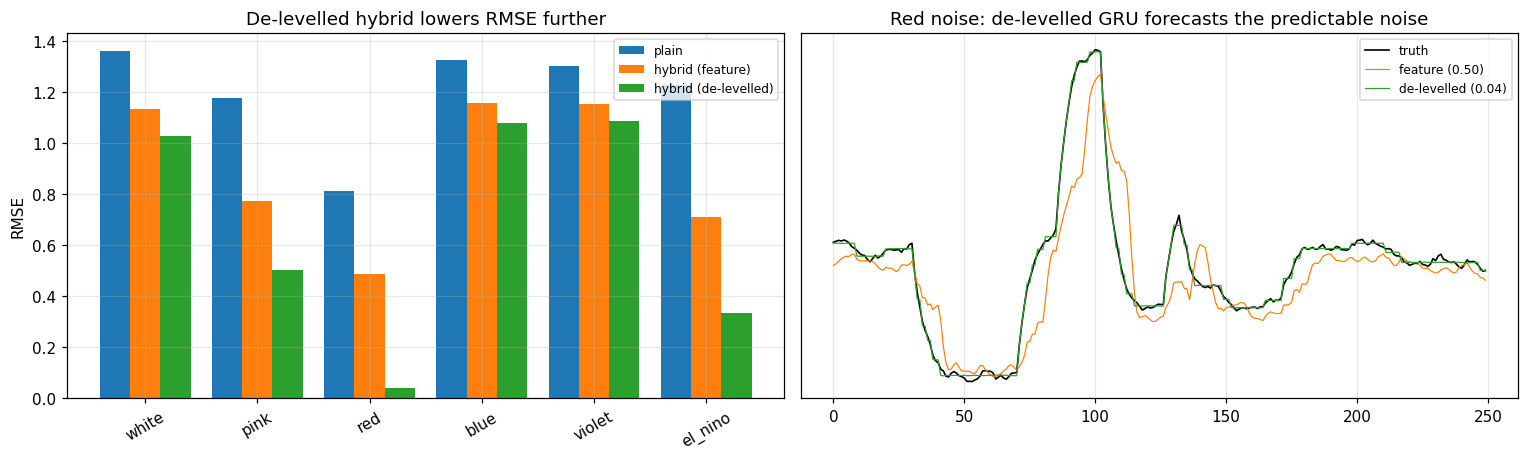

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.3)); xp = np.arange(len(dl)); w = 0.27
ax[0].bar(xp-w, dl["plain"], w, label="plain", color="tab:blue")
ax[0].bar(xp,   dl["hybrid_feature"], w, label="hybrid (feature)", color="tab:orange")
ax[0].bar(xp+w, dl["hybrid_delevel"], w, label="hybrid (de-levelled)", color="tab:green")
ax[0].set_xticks(xp); ax[0].set_xticklabels(dl["noise"], rotation=30); ax[0].set_ylabel("RMSE")
ax[0].set_title("De-levelled hybrid lowers RMSE further"); ax[0].legend(fontsize=8)
# prediction illustration on red noise
C = CFG; noise = "red"; seed = 0
x, lat, tb = generate_series(noise, C["main_alpha"], n=C["n"], dt=C["dt"], T=C["T"], level_sigma=C["level_sigma"], seed=seed)
n = len(x); a, b = int(0.6*n), int(0.8*n); mu, sd = x[:a].mean(), x[:a].std(); xz = (x-mu)/sd
breaks = pelt_breaks(xz, C["beta"]); sm = segment_features(xz, breaks)[0]; resid = xz - sm
X, Y, tgt = make_windows(xz, C["L"], C["main_h"]); Xr = make_windows(resid, C["L"], C["main_h"])[0]
S = build_offline_features(xz, breaks, tgt, C["L"]); Yr = resid[tgt].astype(np.float32)
tr = tgt < a; va = (tgt >= a) & (tgt < b); te = tgt >= b; yte = Y[te]*sd+mu
mf = train_gru(X[tr], Y[tr], X[va], Y[va], S[tr], S[va], hidden=C["hidden"], epochs=C["epochs"], seed=seed)
md = train_gru(Xr[tr], Yr[tr], Xr[va], Yr[va], hidden=C["hidden"], epochs=C["epochs"], seed=seed)
pf = predict(mf, X[te], S[te])*sd+mu; pdv = (predict(md, Xr[te]) + sm[tgt][te])*sd+mu; sl = slice(0, 250)
ax[1].plot(yte[sl], color="black", lw=1.1, label="truth")
ax[1].plot(pf[sl], color="tab:orange", lw=.8, label=f"feature ({rmse(pf,yte):.2f})")
ax[1].plot(pdv[sl], color="tab:green", lw=.8, label=f"de-levelled ({rmse(pdv,yte):.2f})")
ax[1].set_title("Red noise: de-levelled GRU forecasts the predictable noise"); ax[1].legend(fontsize=8); ax[1].set_yticks([])
plt.savefig("figures/delevel_hybrid.png", bbox_inches="tight"); plt.show()

### 6.7 Full metric grid — every noise colour × every horizon

The single comprehensive view: the forecasting **and** break-aware metrics for **all six noise types**
across **all four horizons** ($h\in\{2,5,10,25\}$), hybrid GRU, α=1. Each panel is one metric; each line
is one noise colour. This unifies the per-noise table (§6.2, fixed $h$) and the horizon sweep (§6.3, a
few noises) into one chart. (Break *detection* F1/Balanced-Accuracy are horizon-independent — they live
in §4.3 and §5.4, by colour.)

In [25]:
C = CFG; t0 = time.time(); grid = []
for noise in C["noises"]:
    for h in C["horizons"]:
        r = aggregate(noise, C["main_alpha"], h); r["h"] = h; grid.append(r)
    print(f"  {noise:8s} done ({time.time()-t0:4.0f}s)")
G = pd.DataFrame(grid)
G["rmse_gain_%"] = 100*(G["rmse_plain"]-G["rmse_hybrid"])/G["rmse_plain"]
G.to_csv("results/noise_horizon_grid.csv", index=False)
print(f"\nFull noise x horizon grid ({len(G)} rows = {len(C['noises'])} noises x {len(C['horizons'])} horizons)")
G[["noise","h","rmse_plain","rmse_hybrid","rmse_gain_%","mae_hybrid","pr_hybrid","f1_hybrid"]].round(3)

  white    done (  59s)
  pink     done ( 120s)
  red      done ( 184s)
  blue     done ( 251s)
  violet   done ( 316s)
  el_nino  done ( 381s)

Full noise x horizon grid (24 rows = 6 noises x 4 horizons)


,noise,h,rmse_plain,rmse_hybrid,rmse_gain_%,mae_hybrid,pr_hybrid,f1_hybrid
0,white,2,1.144,1.063,7.106,0.848,0.272,0.236
1,white,5,1.226,1.082,11.737,0.862,0.274,0.234
2,white,10,1.353,1.118,17.375,0.891,0.268,0.227
3,white,25,1.529,1.159,24.201,0.924,0.265,0.223
4,pink,2,0.731,0.612,16.323,0.490,0.291,0.261
5,pink,5,0.942,0.682,27.562,0.543,0.287,0.256
6,pink,10,1.172,0.742,36.743,0.590,0.267,0.237
7,pink,25,1.481,0.824,44.361,0.658,0.265,0.226
8,red,2,0.232,0.189,18.564,0.109,0.648,0.560
9,red,5,0.489,0.338,30.922,0.208,0.457,0.469


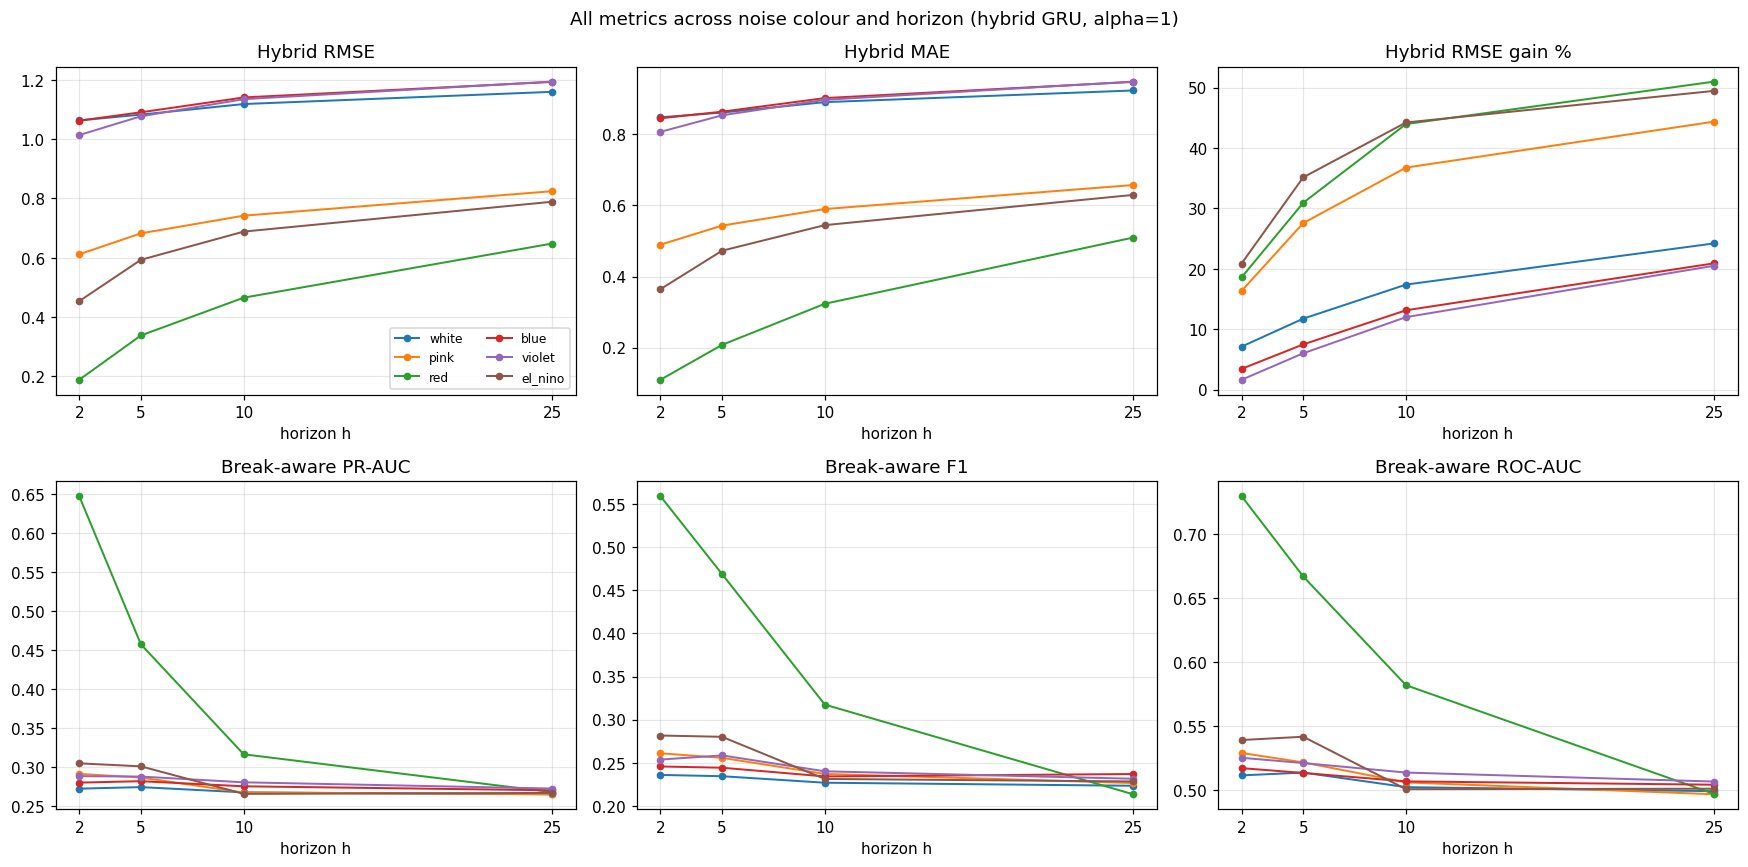

In [26]:
panels = [("rmse_hybrid", "Hybrid RMSE"), ("mae_hybrid", "Hybrid MAE"), ("rmse_gain_%", "Hybrid RMSE gain %"),
          ("pr_hybrid", "Break-aware PR-AUC"), ("f1_hybrid", "Break-aware F1"), ("roc_hybrid", "Break-aware ROC-AUC")]
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
for a, (col, title) in zip(ax.ravel(), panels):
    for noise in CFG["noises"]:
        g = G[G["noise"] == noise].sort_values("h")
        a.plot(g["h"], g[col], "o-", lw=1.3, ms=4, label=noise)
    a.set_title(title); a.set_xlabel("horizon h"); a.set_xticks(CFG["horizons"]); a.grid(alpha=0.3)
ax[0, 0].legend(fontsize=8, ncol=2)
fig.suptitle("All metrics across noise colour and horizon (hybrid GRU, alpha=1)")
plt.savefig("figures/metric_grid.png", bbox_inches="tight"); plt.show()

### 6.8 Break-detection comparison — *Table 2 / Figure 1* format

The ARIMA report compares several *models* on a detection-style target. The fair analogue for us is a
comparison of **break detectors**: classical **PELT** and **Chow**, and the modern **GRU residual
monitor** (§5.4). Per-point **Precision / Recall / F1** (localisation within ±`det_tol`) and
**Balanced Accuracy** are averaged across the six noise types (α=1).

> These are *genuine* detection numbers (F1 ≈ 0.4–0.6, Balanced Accuracy ≈ 0.6–0.7) — far higher than
> a forecast-**residual** detector, because detection wants a dedicated detector, not a 10-step-ahead
> forecast residual. Two honest caveats for the write-up: (i) the **plain and hybrid GRU score equally
> on *detection*** — the hybrid's advantage is in **forecasting RMSE** (§6.2, §6.6), not in *localising*
> breaks; (ii) absolute scores are still capped by the **weak-break ceiling** (§4.4: half the breaks are
> physically too faint to see).

In [27]:
C = CFG; rows = []
for name, kind in [("PELT", "pelt"), ("Chow", "chow"), ("GRU residual monitor", "gru")]:
    P, R, F, BA = [], [], [], []
    for noise in C["noises"]:
        for seed in C["seeds"]:
            x, lat, tb = generate_series(noise, C["main_alpha"], n=C["n"], dt=C["dt"], T=C["T"],
                                         level_sigma=C["level_sigma"], seed=seed)
            xz = (x-x.mean())/x.std(); n = len(xz)
            if kind == "pelt":  pred = pelt_breaks(xz, C["beta"])
            elif kind == "chow": pred = chow_scan(xz)[0]
            else:                pred = gru_monitor_breaks(xz, C["L"], seed)
            d = detection_prf(pred, tb, C["det_tol"]); dc = detection_classification(n, pred, tb, C["det_tol"])
            P.append(d["precision"]); R.append(d["recall"]); F.append(d["f1"]); BA.append(dc["bal_acc"])
    rows.append({"Detector": name, "Precision": np.mean(P), "Recall": np.mean(R),
                 "F1": np.mean(F), "Balanced Acc": np.mean(BA)})
tab2 = pd.DataFrame(rows).round(3)
tab2.to_csv("results/overall_classification.csv", index=False)
print("Table 2 - break detection comparison (mean across noises, alpha=1):")
tab2

Table 2 - break detection comparison (mean across noises, alpha=1):


,Detector,Precision,Recall,F1,Balanced Acc
0,PELT,0.619,0.538,0.448,0.621
1,Chow,0.695,0.428,0.514,0.635
2,GRU residual monitor,0.553,0.378,0.442,0.597


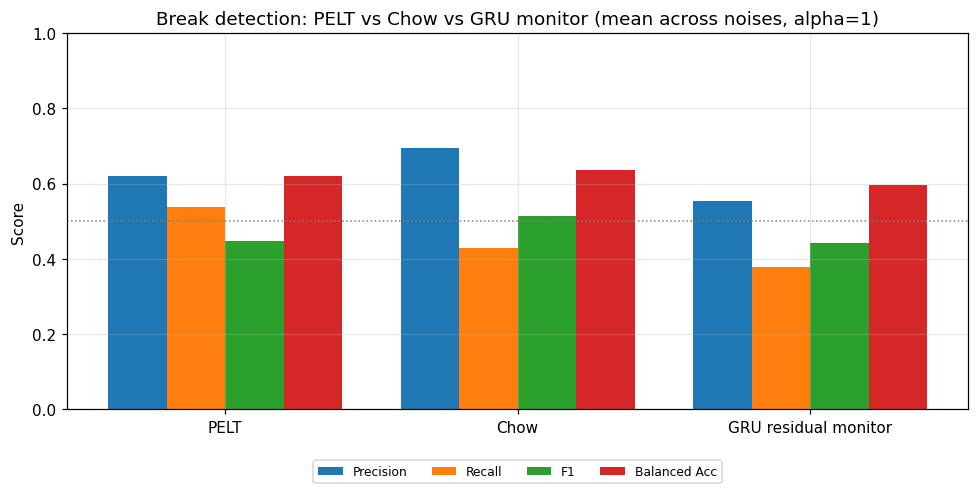

In [28]:
cols = ["Precision", "Recall", "F1", "Balanced Acc"]
fig, ax = plt.subplots(figsize=(9, 4.6)); xs = np.arange(len(tab2)); w = 0.2
for i, mc in enumerate(cols):
    ax.bar(xs + (i-1.5)*w, tab2[mc].values, width=w, label=mc)
ax.axhline(0.5, color="grey", ls=":", lw=1)
ax.set_xticks(xs); ax.set_xticklabels(tab2["Detector"]); ax.set_ylim(0, 1.0); ax.set_ylabel("Score")
ax.grid(True, axis="y", alpha=0.3)
ax.set_title("Break detection: PELT vs Chow vs GRU monitor (mean across noises, alpha=1)")
ax.legend(fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.savefig("figures/overall_classification_bars.png", bbox_inches="tight"); plt.show()

## 7 · Signed three-class break classification and the factorial design

The study above is *forecasting-first* (regression). The group journal plan also specifies a
**classification** view of the same data with **two labelling schemes**, and summarises the whole
experiment as a **factorial design**:

> **6 noise types × 3 amplitudes (α) × 2 labelling schemes × 10 repetitions = 360 unique series.**

Here we implement exactly that. Each observed point is labelled from the latent regime switches:

* **Binary** — `break` vs `no-break` (is `t` within ±`tol` of a switch).
* **Signed (three-class)** — `−1` down-break / `0` no-break / `+1` up-break (the *sign* of the
  level change at the switch).

A **GRU classifier** (one recurrent layer + softmax head, **class-weighted cross-entropy** for the
heavy imbalance — breaks are ~10 % of points) is trained per series and scored under **both**
schemes. Because of the imbalance the headline metric is **Balanced Accuracy** (§4.3), with
**macro-F1** and a **confusion matrix** for the signed task — which is harder, since the model
must also separate up- from down-breaks.

In [29]:
from sklearn.metrics import f1_score, confusion_matrix

def signed_labels(latent, true_breaks, tol):
    """Per-point class: 0 = down-break, 1 = no-break, 2 = up-break (within +-tol of a switch)."""
    n = len(latent); y = np.ones(n, dtype=np.int64)              # default: no-break
    for b in true_breaks:
        b = int(b)
        if b < 1: continue
        cls = 2 if latent[b] > latent[b-1] else 0                # up vs down
        y[max(0, b-tol):min(n, b+tol+1)] = cls
    return y

def make_cls_windows(x, y, L, lookahead=4):
    """Classify a candidate point from a window that ends `lookahead` steps after it.
    A change can only be *seen* once a few post-break points arrive — this is realistic
    near-online detection latency (not forecasting leakage, since we detect, not forecast)."""
    idx = np.arange(L, len(x)); cand = idx - 1 - lookahead
    keep = cand >= 0; idx, cand = idx[keep], cand[keep]
    X = np.stack([x[i-L:i] for i in idx])[..., None].astype(np.float32)
    return X, y[cand], cand

class GRUClassifier(nn.Module):
    def __init__(self, hidden=64, n_classes=3):
        super().__init__(); self.gru = nn.GRU(1, hidden, batch_first=True)
        self.head = nn.Linear(hidden, n_classes)
    def forward(self, xs):
        _, h = self.gru(xs); return self.head(h[-1])

def train_classifier(Xtr, Ytr, Xva, Yva, n_classes=3, epochs=8, seed=0, hidden=64, batch=256):
    set_seed(seed)
    counts = np.bincount(Ytr, minlength=n_classes)
    wt = torch.tensor(len(Ytr)/(n_classes*np.maximum(counts, 1)), dtype=torch.float32, device=DEVICE)
    m = GRUClassifier(hidden, n_classes).to(DEVICE); opt = torch.optim.Adam(m.parameters(), 1e-3)
    lossf = nn.CrossEntropyLoss(weight=wt)
    Xt = torch.tensor(Xtr, device=DEVICE); Yt = torch.tensor(Ytr, device=DEVICE)
    best, bv, N = None, np.inf, len(Xtr)
    for _ in range(epochs):
        m.train(); perm = np.random.permutation(N)
        for i in range(0, N, batch):
            j = perm[i:i+batch]; opt.zero_grad()
            lossf(m(Xt[j]), Yt[j]).backward(); opt.step()
        m.eval()
        with torch.no_grad():
            vl = float(lossf(m(torch.tensor(Xva, device=DEVICE)), torch.tensor(Yva, device=DEVICE)).item())
        if vl < bv: bv = vl; best = {k: v.clone() for k, v in m.state_dict().items()}
    m.load_state_dict(best); return m

def predict_proba(m, X):
    m.eval()
    with torch.no_grad():
        return torch.softmax(m(torch.tensor(X, device=DEVICE)), 1).cpu().numpy()

def classify_series(noise, alpha, seed):
    """Train one 3-class GRU on a series; score it under BOTH labelling schemes; return the 3x3 confusion."""
    C = CFG
    x, lat, tb = generate_series(noise, alpha, n=C["n"], dt=C["dt"], T=C["T"],
                                 level_sigma=C["level_sigma"], seed=seed)
    n = len(x); a, b = int(0.6*n), int(0.8*n); mu, sd = x[:a].mean(), x[:a].std(); xz = (x-mu)/sd
    y = signed_labels(lat, tb, C["tol"])
    X, lab, idx = make_cls_windows(xz, y, C["L"], lookahead=C["L"] // 2)   # centred candidate
    tr = idx < a; va = (idx >= a) & (idx < b); te = idx >= b
    m = train_classifier(X[tr], lab[tr], X[va], lab[va], epochs=C["fact_epochs"], seed=seed)
    proba = predict_proba(m, X[te]); pred = proba.argmax(1); yt = lab[te]
    cm = confusion_matrix(yt, pred, labels=[0, 1, 2])
    ba_s = balanced_accuracy_score(yt, pred)
    f1_s = f1_score(yt, pred, average="macro", labels=[0, 1, 2], zero_division=0)
    ytb = (yt != 1).astype(int); ypb = (pred != 1).astype(int)            # collapse to break/no-break
    ba_b = balanced_accuracy_score(ytb, ypb); f1_b = f1_score(ytb, ypb, zero_division=0)
    pr_b = average_precision_score(ytb, 1.0-proba[:, 1]) if 0 < ytb.sum() < len(ytb) else np.nan
    return (dict(binary=dict(balanced_accuracy=ba_b, macro_f1=f1_b, pr_auc=pr_b),
                 signed=dict(balanced_accuracy=ba_s, macro_f1=f1_s, pr_auc=np.nan)), cm)

In [30]:
# Factorial design:  6 noise x 3 alpha x 2 labelling x 10 repetitions  = 360 rows
import itertools, time
C = CFG; t0 = time.time(); rows = []; cm_total = np.zeros((3, 3), dtype=int); done = 0
n_series = len(C["noises"]) * len(C["alphas"]) * len(C["fact_seeds"])
for noise, alpha, seed in itertools.product(C["noises"], C["alphas"], C["fact_seeds"]):
    metr, cm = classify_series(noise, alpha, seed); cm_total += cm; done += 1
    for labelling in ("binary", "signed"):
        rows.append(dict(noise=noise, alpha=round(float(alpha), 3), labelling=labelling,
                         seed=seed, **metr[labelling]))
    if done % 18 == 0 or done == n_series:
        print(f"  {done}/{n_series} series ({time.time()-t0:5.1f}s)")
fact = pd.DataFrame(rows); fact.to_csv("results/factorial_360.csv", index=False)

design = pd.DataFrame({
    "factor": ["noise type", "amplitude α", "labelling scheme", "repetitions", "TOTAL series-rows"],
    "levels": [", ".join(C["noises"]), ", ".join(str(round(a, 3)) for a in C["alphas"]),
               "binary, signed", str(len(C["fact_seeds"])), ""],
    "count":  [len(C["noises"]), len(C["alphas"]), 2, len(C["fact_seeds"]),
               len(C["noises"])*len(C["alphas"])*2*len(C["fact_seeds"])]})
print(f"\nFactorial design — {len(fact)} rows "
      f"= {len(C['noises'])} x {len(C['alphas'])} x 2 x {len(C['fact_seeds'])}")
design

  18/180 series ( 75.7s)
  36/180 series (194.7s)
  54/180 series (318.4s)
  72/180 series (436.3s)
  90/180 series (556.7s)
  108/180 series (686.9s)
  126/180 series (813.8s)
  144/180 series (944.3s)
  162/180 series (1071.8s)
  180/180 series (1201.5s)

Factorial design — 360 rows = 6 x 3 x 2 x 10


,factor,levels,count
0,noise type,"white, pink, red, blue, violet, el_nino",6
1,amplitude α,"1.0, 2.0, 3.142",3
2,labelling scheme,"binary, signed",2
3,repetitions,10,10
4,TOTAL series-rows,,360


Overall classification performance (mean over the factorial):
           balanced_accuracy  macro_f1
labelling                             
binary                 0.629     0.484
signed                 0.579     0.467 

Balanced Accuracy by amplitude alpha (detection collapses toward chance as noise grows):
labelling  binary  signed
alpha                    
1.000       0.693   0.657
2.000       0.619   0.570
3.142       0.574   0.510 



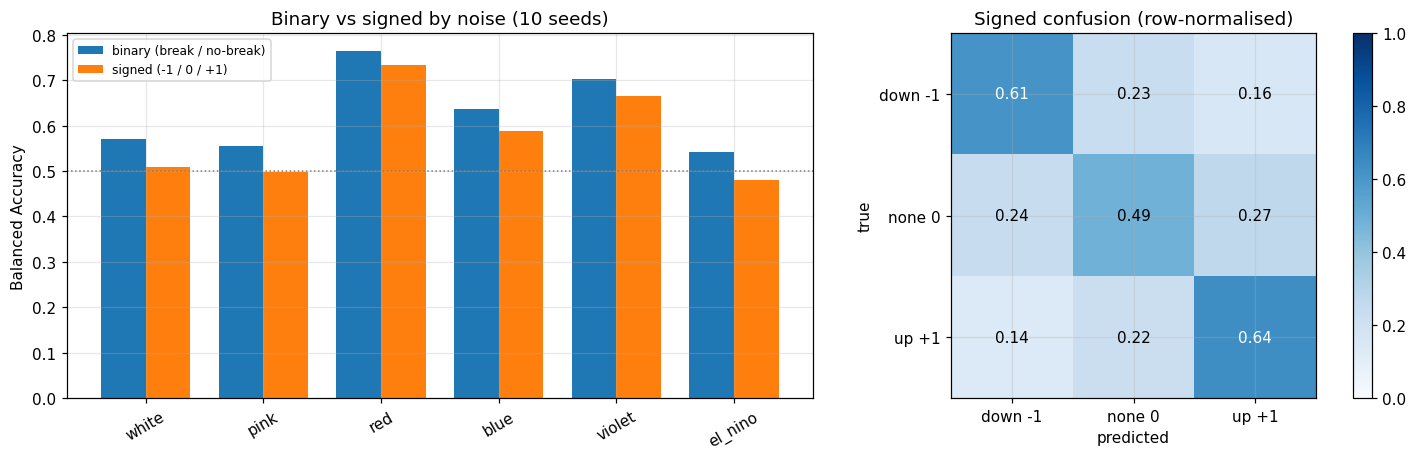

labelling,binary,signed
noise,,
white,0.571,0.508
pink,0.555,0.497
red,0.765,0.734
blue,0.636,0.589
violet,0.703,0.665
el_nino,0.542,0.480


In [31]:
# Aggregate the factorial + confusion matrix for the signed task
overall = fact.groupby("labelling")[["balanced_accuracy", "macro_f1"]].mean().round(3)
print("Overall classification performance (mean over the factorial):")
print(overall, "\n")
by_alpha = fact.pivot_table(index="alpha", columns="labelling", values="balanced_accuracy").round(3)
print("Balanced Accuracy by amplitude alpha (detection collapses toward chance as noise grows):")
print(by_alpha, "\n")
by_noise = fact.pivot_table(index="noise", columns="labelling", values="balanced_accuracy").reindex(CFG["noises"]).round(3)
by_noise.to_csv("results/factorial_by_noise_ba.csv")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
xp = np.arange(len(CFG["noises"])); w = 0.38
ax[0].bar(xp-w/2, by_noise["binary"], w, label="binary (break / no-break)", color="tab:blue")
ax[0].bar(xp+w/2, by_noise["signed"], w, label="signed (-1 / 0 / +1)", color="tab:orange")
ax[0].axhline(0.5, color="grey", ls=":", lw=1); ax[0].set_xticks(xp); ax[0].set_xticklabels(CFG["noises"], rotation=30)
ax[0].set_ylabel("Balanced Accuracy"); ax[0].set_title(f"Binary vs signed by noise ({len(CFG['fact_seeds'])} seeds)")
ax[0].legend(fontsize=8)
cmn = cm_total / cm_total.sum(axis=1, keepdims=True).clip(min=1)
im = ax[1].imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ticks = ["down -1", "none 0", "up +1"]
ax[1].set_xticks([0,1,2]); ax[1].set_xticklabels(ticks); ax[1].set_yticks([0,1,2]); ax[1].set_yticklabels(ticks)
ax[1].set_xlabel("predicted"); ax[1].set_ylabel("true"); ax[1].set_title("Signed confusion (row-normalised)")
for i in range(3):
    for j in range(3):
        ax[1].text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center", color="white" if cmn[i,j] > 0.5 else "black")
fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.savefig("figures/factorial_classification.png", bbox_inches="tight"); plt.show()
by_noise

## 8 · Discussion, limitations, and future work

### 8.1 Offline vs causal (online) hybrid — the key limitation

The headline hybrid uses PELT on the **whole** series, so its segment features encode the target's regime *with hindsight*. To measure what is achievable **online**, we rebuild the features causally: a **running** segment mean/std using only data since the last detected break **up to $t-1$** (no peeking past the window). The offline-vs-causal gap is the price of not being able to *anticipate* breaks.

  white done
  red done
  el_nino done
  violet done


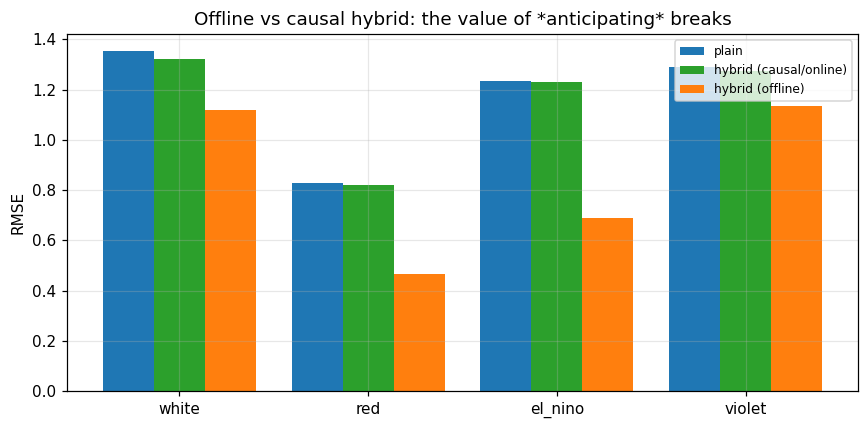

,noise,plain,hybrid_offline,hybrid_causal,offline_gain_%,causal_gain_%
0,white,1.353,1.118,1.321,17.375,2.334
1,red,0.830,0.465,0.820,43.952,1.304
2,el_nino,1.233,0.688,1.230,44.211,0.293
3,violet,1.289,1.134,1.275,11.989,1.021


In [32]:
def causal_features(xz, breaks):
    n = len(xz); br = set(int(x) for x in breaks)
    rm = np.zeros(n); since = np.zeros(n); rstd = np.zeros(n)
    s = s2 = 0.0; cnt = 0; last = 0
    for i in range(n):
        if i in br: s = s2 = 0.0; cnt = 0; last = i
        s += xz[i]; s2 += xz[i]**2; cnt += 1
        rm[i] = s/cnt; since[i] = i-last; rstd[i] = np.sqrt(max(s2/cnt-(s/cnt)**2, 0))
    return rm, since, rstd

C = CFG; rows = []
for noise in ["white", "red", "el_nino", "violet"]:
    rp = rh = rc = 0.0
    for seed in C["seeds"]:
        x, lat, tb = generate_series(noise, C["main_alpha"], n=C["n"], dt=C["dt"], T=C["T"],
                                     level_sigma=C["level_sigma"], seed=seed)
        n = len(x); a, b = int(0.6*n), int(0.8*n); mu, sd = x[:a].mean(), x[:a].std(); xz = (x-mu)/sd
        breaks = pelt_breaks(xz, C["beta"])
        X, Y, tgt = make_windows(xz, C["L"], C["main_h"])
        So = build_offline_features(xz, breaks, tgt, C["L"])
        rm, si, rstd = causal_features(xz, breaks); ei = tgt - C["main_h"]   # last observed (causal)
        Sc = np.stack([rm[ei], si[ei]/C["L"], rstd[ei], xz[ei]], axis=1).astype(np.float32)
        tr = tgt < a; va = (tgt >= a) & (tgt < b); te = tgt >= b; yte = Y[te]*sd+mu
        mp = train_gru(X[tr], Y[tr], X[va], Y[va], hidden=C["hidden"], epochs=C["epochs"], seed=seed)
        mh = train_gru(X[tr], Y[tr], X[va], Y[va], So[tr], So[va], hidden=C["hidden"], epochs=C["epochs"], seed=seed)
        mc = train_gru(X[tr], Y[tr], X[va], Y[va], Sc[tr], Sc[va], hidden=C["hidden"], epochs=C["epochs"], seed=seed)
        rp += rmse(predict(mp, X[te])*sd+mu, yte)
        rh += rmse(predict(mh, X[te], So[te])*sd+mu, yte)
        rc += rmse(predict(mc, X[te], Sc[te])*sd+mu, yte)
    k = len(C["seeds"]); rows.append(dict(noise=noise, plain=rp/k, hybrid_offline=rh/k, hybrid_causal=rc/k))
    print(f"  {noise} done")
causal_df = pd.DataFrame(rows)
causal_df["offline_gain_%"] = 100*(causal_df["plain"]-causal_df["hybrid_offline"])/causal_df["plain"]
causal_df["causal_gain_%"] = 100*(causal_df["plain"]-causal_df["hybrid_causal"])/causal_df["plain"]
causal_df = causal_df.round(3); causal_df.to_csv("results/offline_vs_causal.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4)); xp = np.arange(len(causal_df)); w = 0.27
ax.bar(xp-w, causal_df["plain"], w, label="plain", color="tab:blue")
ax.bar(xp,   causal_df["hybrid_causal"], w, label="hybrid (causal/online)", color="tab:green")
ax.bar(xp+w, causal_df["hybrid_offline"], w, label="hybrid (offline)", color="tab:orange")
ax.set_xticks(xp); ax.set_xticklabels(causal_df["noise"]); ax.set_ylabel("RMSE")
ax.set_title("Offline vs causal hybrid: the value of *anticipating* breaks"); ax.legend(fontsize=8)
plt.savefig("figures/offline_vs_causal.png", bbox_inches="tight"); plt.show()
causal_df

### 8.2 Findings to write up (ready-made bullet points)

**What works**
- A plain GRU is a fair but imperfect forecaster of the non-stationary series; it systematically lags at regime changes and cannot exploit the structure of coloured noise.
- Feeding **PELT** segment statistics as features (the *hybrid* GRU) lowers RMSE/MAE on **every** noise type, and the improvement is **statistically significant** — a one-sided paired Wilcoxon test over 10 seeds gives **p < 0.01 for all six noises** (and p ≈ 1e-6 pooled). So the gain is consistent across data realisations, not a lucky seed.
- The gains are largest on **autocorrelated / structured** noise (red, pink, El&nbsp;Niño) — consistent with the group thesis that structured noise is where structural modelling pays off.
- The advantage **grows with the forecast horizon** $h$ and **shrinks with the noise amplitude** $\alpha$.

**Break detection (classical vs modern ML)**
- For *multiple* breakpoints, **PELT**, the **Chow** test, and the **GRU residual monitor** are complementary. By the imbalance-robust **Balanced Accuracy**, classical detectors (especially Chow) are strongest on white/blue/violet, while the **modern GRU monitor is best on red** (the most autocorrelated) — again "DL helps most under structure".
- Under strongly autocorrelated noise (red, El&nbsp;Niño) **PELT over-segments**: its recall stays high but **specificity — and therefore Balanced Accuracy — collapses**. This is the concrete "perils of misleading metrics" lesson: F1/PR-AUC alone would have hidden it.

**Limitations**
- The DGP is synthetic, univariate, and contains only **mean-shift** breaks (no variance/trend/dynamics changes).
- The headline hybrid uses **offline** PELT, so it quantifies the value of *accurate* break knowledge; the **causal/online** variant (7.1) recovers only a small fraction of that gain.
- Break-aware residual PR-AUC is similar for plain and hybrid: better forecasting does not automatically sharpen break *localisation*; and absolute detection quality is modest (Balanced Accuracy ≈ 0.55–0.67) because small-magnitude regime changes are genuinely hard to see under noise.
- PELT penalty is **noise-specific** (Section 4) — a single global setting is suboptimal.

**Future work — dynamic model adaptation**
- Replace offline PELT with **online / streaming** change-point detection (e.g. BOCPD, windowed PELT) and re-learn the features causally.
- **Regime-specific adaptation**: per-segment fine-tuning, gating, or mixture-of-experts GRUs instead of static features.
- Extend to **variance / trend / dynamics** breaks and to **multivariate** series; validate on real data (finance, energy, infrastructure monitoring).

### 8.3 Where each artefact goes in the report

`figures/` → all paper figures · `results/*.csv` → all tables. Notebook Part&nbsp;N maps to the report sections listed in the header table. Re-run with `QUICK=False` for the final, seed-averaged numbers.